# Trump Rally Transcripts — NLP Analysis



**How to run**
1. *Runtime → Change runtime type → **T4 GPU*** (strongly recommended).
2. *Runtime → **Run all***.



## 0. Install packages

In [1]:
# quiet install: only prints a short error if something fails
import subprocess, sys

def _quiet_run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"FAILED: {' '.join(cmd[2:])}\n{(r.stderr or r.stdout)[-1500:]}")
    return r.returncode == 0

ok = _quiet_run([sys.executable, "-m", "pip", "install", "-q", "bertopic", "optuna"])
ok &= _quiet_run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
print("Packages ready." if ok else "Some installs failed (see above).")

Packages ready.


## 0.1 Imports & settings

In [2]:
# ---- quiet, static output (set before any model library is imported) ------
import os, io, logging, contextlib, warnings
os.environ.update({"TOKENIZERS_PARALLELISM": "false", "TRANSFORMERS_VERBOSITY": "error",
                   "HF_HUB_DISABLE_PROGRESS_BARS": "1", "HF_HUB_VERBOSITY": "error",
                   "HF_HUB_DISABLE_TELEMETRY": "1", "TF_CPP_MIN_LOG_LEVEL": "3",
                   "USE_TF": "0", "USE_TORCH": "1", "PYTHONWARNINGS": "ignore"})
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None    # nothing printed even if a library resets the filters
logging.disable(logging.WARNING)                         # hides library WARNING/INFO logs (e.g. BERTopic); errors still show
%matplotlib inline
%config InlineBackend.figure_format = "png"

import re, math, time, random, textwrap
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display, clear_output

try:
    import transformers
    transformers.logging.set_verbosity_error()
    transformers.logging.disable_progress_bar()
except Exception:
    pass
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()                              # no download bars (they are widgets and vanish on download)
except Exception:
    pass

@contextlib.contextmanager
def quiet():
    """Swallow anything a library prints while loading a model (load reports, HF token notes)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        yield

def show_table(frame):
    """Static table (plain HTML + text fallback): no interactive Colab table, survives downloading."""
    display({"text/html": frame.to_html(), "text/plain": frame.to_string()}, raw=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

HAS_GPU = torch.cuda.is_available()
PIPE_DEVICE = 0 if HAS_GPU else -1
TORCH_DEVICE = "cuda" if HAS_GPU else "cpu"

# ---- user settings --------------------------------------------------------
FAST_MODE = False                      # True -> one seed and fewer trials (quick check)
SEARCH_SEEDS = [42] if FAST_MODE else [42, 7, 2024]   # every configuration is scored on all of these
N_TRIALS = 12 if FAST_MODE else 30     # trials per joint-search strategy (Random and TPE)
MIN_TOPICS = 6                         # a configuration must produce at least this many topics
MAX_TOPICS = 25                        # ...and at most this many
MAX_OUTLIER_SHARE = 0.35               # ...and leave at most this share unassigned (after reassignment)
COVERAGE_TOPN = 5                      # keyword F1 uses each topic's top-N terms
COHERENCE_MEASURE = "c_v"              # coherence inside the fit: "c_v" or "c_npmi" (rescaled to 0..1)
MIN_CONTENT_WORDS = 3                  # sentences with fewer content words carry no topic -> dropped
DEDUP_THRESHOLD = 0.92                 # cosine similarity above which two sentences count as the same line
ALLOW_LEXICAL_EMBEDDINGS = False       # True lets the optimiser pick embeddings of the bag-of-words text
USE_ZEROSHOT = True                    # also try guided (zero-shot) topics, Section 12 Stage H
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
LABEL_BACKEND = "qwen"                 # "qwen" (small instruct model, better titles) or "flan-t5"
QWEN_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LABEL_MODEL = "google/flan-t5-large"   # used if LABEL_BACKEND == "flan-t5" or Qwen cannot be loaded
DATA_PATH = "/content/Trump_Rallies_Dataset.csv"
# ---------------------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
print("GPU available:", HAS_GPU, "| seeds per configuration:", len(SEARCH_SEEDS))

GPU available: True | seeds per configuration: 3


## 1. Setup & Data Loading
Loads the 103 rally transcripts (one row per rally: `Place`, `Date`, `Transcript`) and parses the dates so rallies can be ordered chronologically.

In [3]:
# upload the csv only if it isn't there yet
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Please upload Trump_Rallies_Dataset.csv")
        uploaded = files.upload()
        fname = next(iter(uploaded))
        if os.path.abspath(fname) != DATA_PATH:
            os.replace(fname, DATA_PATH)
        clear_output()                                   # remove the upload widget from the saved output
        print("Uploaded", fname)
    except ImportError:
        raise FileNotFoundError(f"Place the CSV at {DATA_PATH} or edit DATA_PATH.")

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df = df.dropna(subset=["Transcript"]).reset_index(drop=True)

df["Date_parsed"] = pd.to_datetime(df["Date"].astype(str).str.strip(), format="%B %d %Y", errors="coerce")
missing = df["Date_parsed"].isna()
if missing.any():
    df.loc[missing, "Date_parsed"] = pd.to_datetime(df.loc[missing, "Date"], errors="coerce")
df["Place_short"] = (df["Place"].astype(str)
                     .str.replace(r"^Speech:\s*Donald Trump Holds a (Campaign )?Rally in\s*", "", regex=True)
                     .str.strip())

texts = df["Transcript"].tolist()
print("Shape:", df.shape, "| unparsed dates:", int(df["Date_parsed"].isna().sum()))
show_table(df[["Place_short", "Date", "Date_parsed"]].head())

Shape: (103, 5) | unparsed dates: 0


,Place_short,Date,Date_parsed
0,"Sanford, Florida",October 12 2020,2020-10-12
1,"Duluth, Minnesota",September 30 2020,2020-09-30
2,"Middletown, Pennsylvania",September 26 2020,2020-09-26
3,"Newport News, Virginia",September 25 2020,2020-09-25
4,"Jacksonville, Florida",September 24 2020,2020-09-24


## 2. Inspecting a Sample Transcript

In [4]:
IDX = 92 if len(df) > 92 else 0
sample = df.loc[IDX, "Transcript"]
print(f"Transcript {IDX} - {df.loc[IDX, 'Place_short']} ({df.loc[IDX, 'Date']}), {len(sample.split()):,} words\n")
print(textwrap.fill(sample[:3000], 130), "...")

Transcript 92 - Speech: Donald Trump Holds a Political Rally in Pensacola, Florida (December 8 2017), 9,454 words

Thank you. Thank you. [Applause, Crowd chants USA] Thank you, everybody. Thank you. And if you think this crowd is big, you should
see right now what's outside. Congratulations. [Applause] Hello, Pensacola. What a place. Right here on the Emerald Coast, right?
The Emerald Coast in the great state of Florida where we had a tremendous victory, didn't we? Come on. [Applause] We are joined by
many, many people in the military and great American patriots. Thank you very much. [Applause] When you remember the campaign, I
said, let me begin by wishing each and every one of you a very Merry Christmas. Right? [Applause] And I can think of no better
Christmas present for the American people than giving you a massive tax cut. That is what's happening. [Applause] And your Senate
and your House hopefully very shorty will have those approvals. Those heads will go up and you will be payi

## 3. Named Entity Recognition — Who Gets Mentioned
spaCy `en_core_web_sm` extracts PERSON entities from every transcript (run once and reused in Section 4). Stage-direction artefacts such as "Audience Boos" are filtered out.

NER done in 167s


,Entity,Frequency
0,Trump,498
1,Obama,327
2,Biden,303
3,Donald Trump,253
4,Joe,248
5,Joe Biden,193
6,Nancy Pelosi,169
7,Bernie,164
8,Mike,153
9,Hillary,116


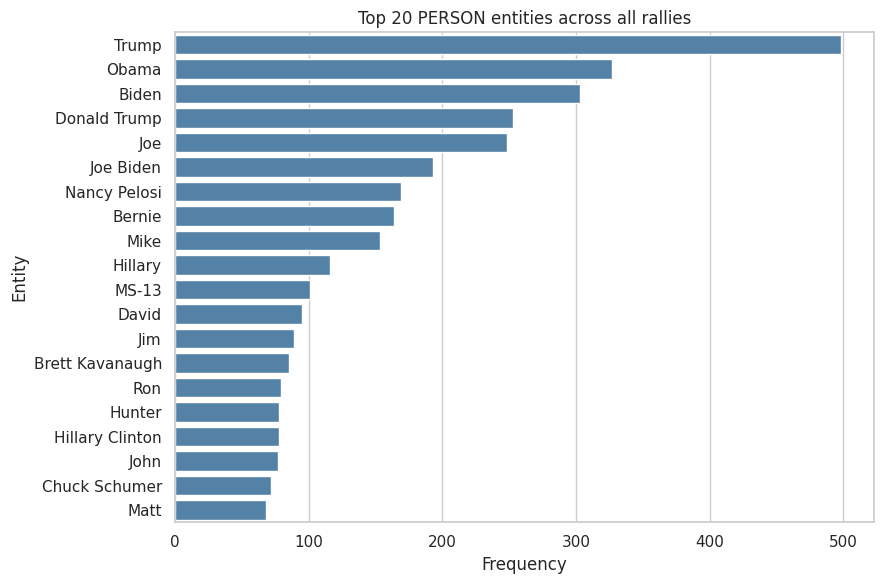

In [5]:
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import en_core_web_sm
    nlp = en_core_web_sm.load()
nlp.max_length = 3_000_000

NOISE = re.compile(r"[\[\]\"]|\baudience\b|\bcrowd\b|applause|\bboos?\b|\bbooing\b|chant|inaudible", re.I)
ner_disable = [p for p in ("tagger", "parser", "attribute_ruler", "lemmatizer") if p in nlp.pipe_names]

t0 = time.time()
persons_per_doc = []
with nlp.select_pipes(disable=ner_disable):
    for doc in nlp.pipe(texts, batch_size=4):
        persons_per_doc.append([e.text.strip() for e in doc.ents
                                if e.label_ == "PERSON" and not NOISE.search(e.text)])
df["persons"] = persons_per_doc
print(f"NER done in {time.time() - t0:.0f}s")

person_counts = Counter(p for plist in persons_per_doc for p in plist)
top_20_person_entities = pd.DataFrame(person_counts.most_common(20), columns=["Entity", "Frequency"])
show_table(top_20_person_entities)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_20_person_entities, y="Entity", x="Frequency", color="steelblue")
plt.title("Top 20 PERSON entities across all rallies")
plt.tight_layout(); plt.show()

## 4. Tracking Democratic-Figure Mentions Over Time
Fix: the original cell used an undefined `dates` variable. Here the per-rally counts are aligned with the parsed dates, sorted chronologically and split by person so you can see *who* drives the peaks.

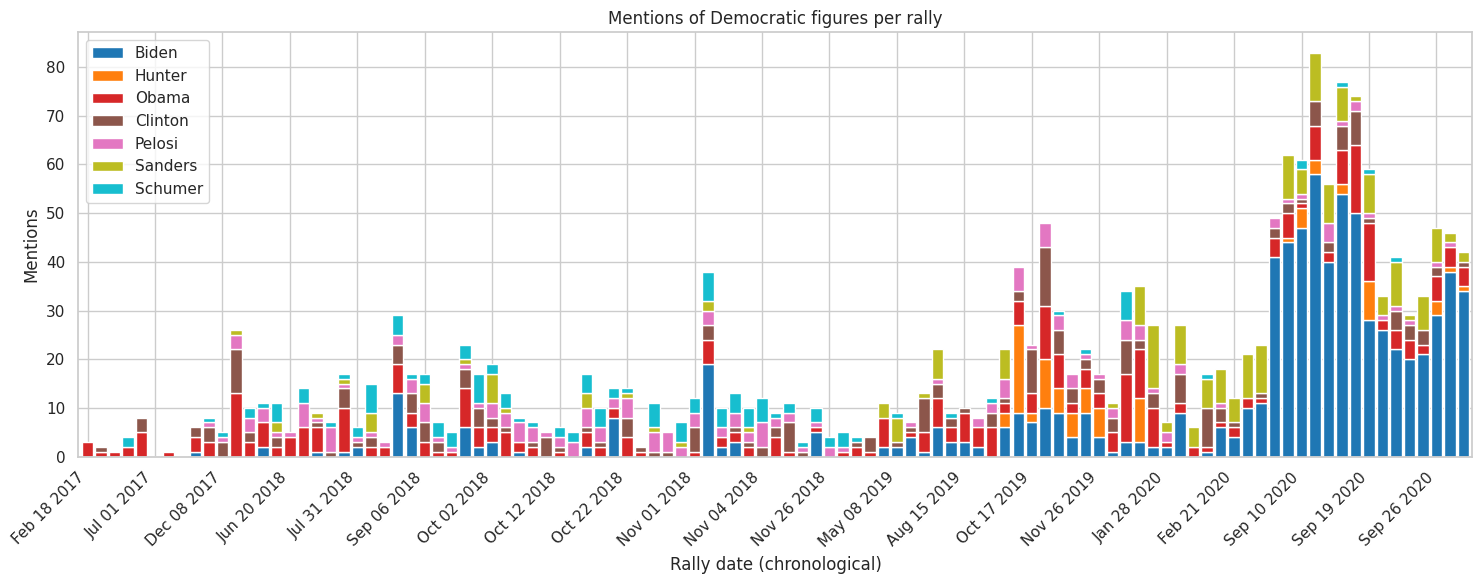

In [6]:
GROUPS = {
    "Biden":   {"Biden", "Joe", "Joe Biden", "Sleepy Joe", "Sleepy Joe Biden"},
    "Hunter":  {"Hunter", "Hunter Biden"},
    "Obama":   {"Obama", "Barack Obama"},
    "Clinton": {"Hillary", "Hillary Clinton", "Clinton"},
    "Pelosi":  {"Nancy Pelosi", "Pelosi"},
    "Sanders": {"Bernie", "Bernie Sanders"},
    "Schumer": {"Chuck Schumer", "Schumer"},
}
name2group = {n: g for g, names in GROUPS.items() for n in names}

rows = []
for i, plist in enumerate(df["persons"]):
    c = Counter(name2group[p] for p in plist if p in name2group)
    rows.append({"Date": df.loc[i, "Date_parsed"], **{g: c.get(g, 0) for g in GROUPS}})
mentions_df = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
mentions_df["Total"] = mentions_df[list(GROUPS)].sum(axis=1)

ax = mentions_df[list(GROUPS)].plot(kind="bar", stacked=True, figsize=(15, 6), width=0.85, colormap="tab10")
# only label every 5th date so the axis stays readable
n = 5
ax.set_xticks(range(0, len(mentions_df), n))
ax.set_xticklabels(mentions_df["Date"].dt.strftime("%b %d %Y").iloc[::n], rotation=45, ha="right")
ax.set_xlabel("Rally date (chronological)"); ax.set_ylabel("Mentions")
ax.set_title("Mentions of Democratic figures per rally")
plt.tight_layout(); plt.show()

## 5. Transcript Similarity (TF-IDF + Cosine Similarity)
Pairwise cosine similarity between all rallies — bright blocks mean reused material. The table lists the most similar pairs.

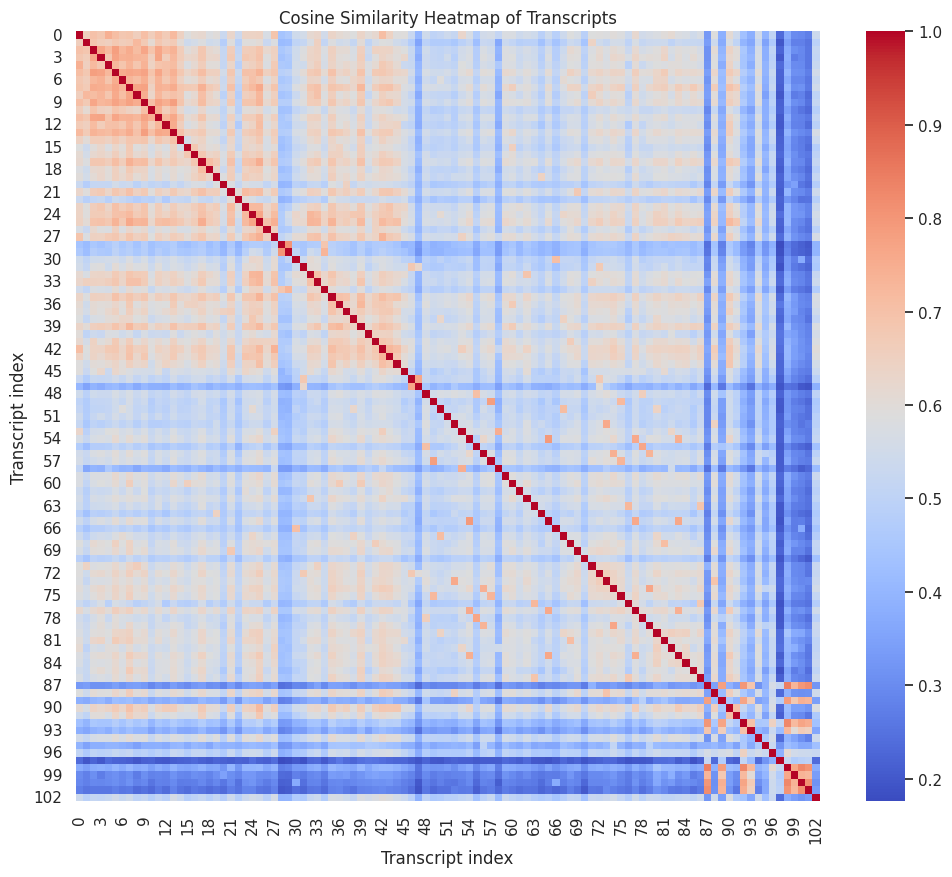

,A,B,cosine,A rally,B rally
0,87,98,0.844,Speech: Donald Trump Holds a Political R (June 20 2018),Speech: Donald Trump Holds a Political R (June 21 2017)
1,98,100,0.827,Speech: Donald Trump Holds a Political R (June 21 2017),Speech: Donald Trump Holds a Political R (March 20 2017)
2,92,98,0.827,Speech: Donald Trump Holds a Political R (December 8 2017),Speech: Donald Trump Holds a Political R (June 21 2017)
3,87,101,0.817,Speech: Donald Trump Holds a Political R (June 20 2018),Speech: Donald Trump Holds a Political R (March 15 2017)
4,100,101,0.811,Speech: Donald Trump Holds a Political R (March 20 2017),Speech: Donald Trump Holds a Political R (March 15 2017)
5,98,101,0.807,Speech: Donald Trump Holds a Political R (June 21 2017),Speech: Donald Trump Holds a Political R (March 15 2017)
6,28,29,0.801,Speech: Donald Trump Holds a Political R (November 14 2019),Speech: Donald Trump Holds a Political R (November 6 2019)
7,87,100,0.798,Speech: Donald Trump Holds a Political R (June 20 2018),Speech: Donald Trump Holds a Political R (March 20 2017)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_matrix = TfidfVectorizer(stop_words="english").fit_transform(texts)
sim = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(sim, cmap="coolwarm")
plt.title("Cosine Similarity Heatmap of Transcripts")
plt.xlabel("Transcript index"); plt.ylabel("Transcript index")
plt.show()

iu = np.triu_indices_from(sim, k=1)
order = np.argsort(sim[iu])[::-1][:8]
pairs = pd.DataFrame({"A": iu[0][order], "B": iu[1][order], "cosine": sim[iu][order].round(3)})
pairs["A rally"] = pairs["A"].map(lambda i: f"{df.Place_short[i][:40]} ({df.Date[i]})")
pairs["B rally"] = pairs["B"].map(lambda i: f"{df.Place_short[i][:40]} ({df.Date[i]})")
show_table(pairs)

## 6. Extracting Audience / Crowd Reactions
Every bracketed cue is captured with the text before it, then **non-crowd tags such as `[Inaudible]` are removed**. The *Preceding Phrase* is the last two sentences spoken before the reaction (the original kept the whole chunk since the previous tag, which can run to hundreds of words).

In [8]:
TAG_RE = re.compile(r"\[[^\]]+\]")
CROWD_RE = re.compile(r"audience|crowd|applause|cheer|\bboo|chant|laugh|clap|yell|shout|scream", re.I)
SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")

# pair each [tag] with the text that came right before it
def extract_reactions(transcript):
    out, last = [], 0
    for m in TAG_RE.finditer(transcript):
        out.append((transcript[last:m.start()].strip(), m.group(0).strip()))
        last = m.end()
    return out

def last_sentences(text, k=2):
    sents = [s.strip() for s in SENT_SPLIT.split(TAG_RE.sub(" ", text)) if len(s.strip()) > 1]
    return re.sub(r"\s+", " ", " ".join(sents[-k:])).strip()

def reaction_type(tag):
    t = tag.lower()
    if "boo" in t:   return "Boos"
    if "laugh" in t: return "Laughter"
    if "chant" in t: return "Chant"
    if any(x in t for x in ("applause", "cheer", "clap")): return "Applause/Cheers"
    return "Other crowd"

rows = []
for i, tr in enumerate(texts):
    for prec, tag in extract_reactions(tr):
        rows.append({"doc_id": i, "Date": df.loc[i, "Date_parsed"], "Preceding Text": prec, "Crowd Reaction": tag})
reaction_all = pd.DataFrame(rows)

reaction_df = reaction_all[reaction_all["Crowd Reaction"].str.contains(CROWD_RE)].copy()
reaction_df["Preceding Phrase"] = reaction_df["Preceding Text"].apply(last_sentences)
reaction_df = reaction_df[reaction_df["Preceding Phrase"].str.split().str.len() >= 3].reset_index(drop=True)
reaction_df["Reaction Type"] = reaction_df["Crowd Reaction"].apply(reaction_type)

print(f"All bracketed tags: {len(reaction_all):,} | crowd reactions kept: {len(reaction_df):,}")
print(reaction_df["Reaction Type"].value_counts())
show_table(reaction_df[["Preceding Phrase", "Crowd Reaction", "Reaction Type"]].head())

All bracketed tags: 2,725 | crowd reactions kept: 2,501
Reaction Type
Applause/Cheers    1006
Boos                690
Chant               403
Laughter            239
Other crowd         163
Name: count, dtype: int64


,Preceding Phrase,Crowd Reaction,Reaction Type
0,Thank you. It's great to be back.,"[Audience chants ""USA""]",Chant
1,"It's you know, here we are. But we're going to finish, we're going to make this country greater than ever before.","[Audience chants ""We love you""]",Chant
2,We're going to win four more years in the White House. We're going to make our country greater than it has ever been before.,"[Audience chants ""USA""]",Chant
3,"Most important we've ever had. Biden has made a corrupt bargain exchange for his party's nomination, he's handed control to the Socialists, the Marxists, and the left-wing extremists and you know that and he's got no strength left, he's got no power left.",[Audience Boos],Boos
4,"Don't blow it, don't blow it. Sleepy Joe wants to quadruple your taxes, you know, wants to quadruple.",[Audience Boos],Boos


## 7. Sentiment of Crowd Reactions — SentiWordNet (original method)
Kept for comparison. Scoring the words inside a tag like `[Audience Boos]` with a dictionary is a weak signal, which is why Section 7b adds a transformer model applied to what was actually said.

In [9]:
import nltk
for pkg in ("sentiwordnet", "wordnet", "omw-1.4", "punkt", "punkt_tab"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import sentiwordnet as swn
from nltk.tokenize import word_tokenize

def analyze_sentiment_swn(text):
    score, count = 0.0, 0
    for tok in word_tokenize(re.sub(r"[\[\]\"]", " ", text)):
        syns = list(swn.senti_synsets(tok.lower()))
        if syns:
            score += syns[0].pos_score() - syns[0].neg_score()
            count += 1
    if count == 0:
        return np.nan
    avg = score / count
    return 1 if avg > 0 else (0 if avg < 0 else np.nan)

reaction_df["SWN Label"] = reaction_df["Crowd Reaction"].apply(analyze_sentiment_swn)
print("SentiWordNet label by reaction type (NaN = neutral/unscored):")
show_table(pd.crosstab(reaction_df["Reaction Type"], reaction_df["SWN Label"].map({1: "positive", 0: "negative"}).fillna("neutral")))

SentiWordNet label by reaction type (NaN = neutral/unscored):


SWN Label,negative,neutral,positive
Reaction Type,,,
Applause/Cheers,1,58,947
Boos,545,145,0
Chant,9,363,31
Laughter,0,239,0
Other crowd,32,97,34


## 7b. Transformer Sentiment of the Speech (Twitter-RoBERTa)
Labels each *Preceding Phrase* as negative / neutral / positive with `cardiffnlp/twitter-roberta-base-sentiment-latest`, then compares that with how the crowd reacted.
This replaces the external `filtered_phrases_nouns_verbs.xlsx`: the same kind of table (`Filtered_phrase` = nouns, proper nouns and verbs of the phrase, `label` = 1 positive / 0 negative) is rebuilt here from the original transcripts.

Scored 2,501 phrases in 9s


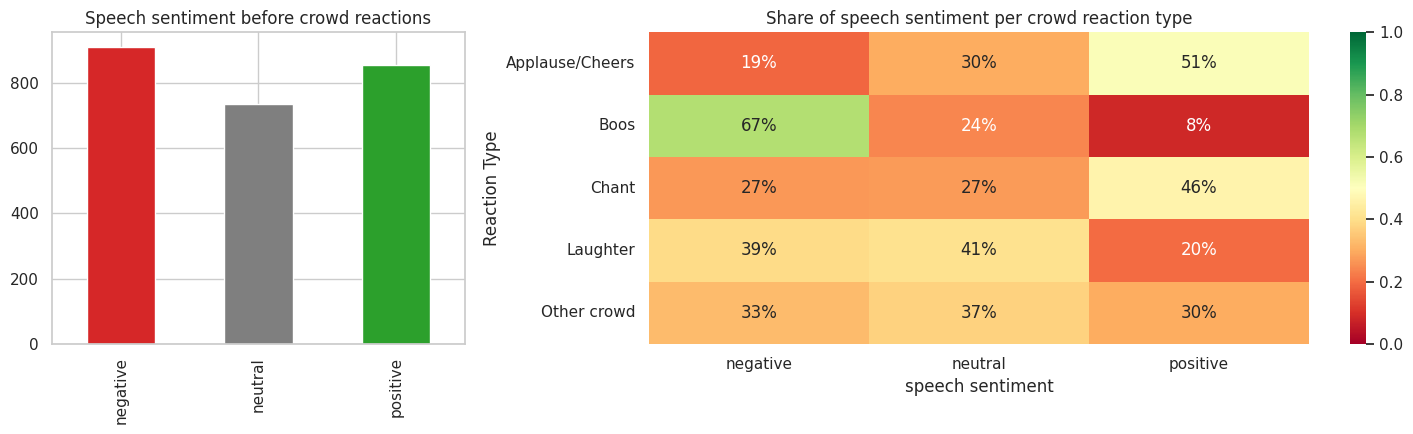

Labelled phrase set: (1736, 11) | positive share: 0.487


,Preceding Phrase,Filtered_phrase,label,Reaction Type
0,Thank you. It's great to be back.,thank,1,Chant
1,"It's you know, here we are. But we're going to finish, we're going to make this country greater than ever before.",know going finish going country,1,Chant
2,We're going to win four more years in the White House. We're going to make our country greater than it has ever been before.,going win years white house going country,1,Chant
3,"Most important we've ever had. Biden has made a corrupt bargain exchange for his party's nomination, he's handed control to the Socialists, the Marxists, and the left-wing extremists and you know that and he's got no strength left, he's got no power left.",biden bargain exchange party nomination handed control socialists marxists wing extremists know got strength left got power left,0,Boos
4,"Don't blow it, don't blow it. Sleepy Joe wants to quadruple your taxes, you know, wants to quadruple.",blow blow sleepy joe wants quadruple taxes know wants quadruple,0,Boos


In [10]:
from transformers import pipeline

with quiet():
    sent_pipe = pipeline("text-classification", model=SENTIMENT_MODEL, tokenizer=SENTIMENT_MODEL, device=PIPE_DEVICE)

def roberta_sentiment(text_list, batch_size=32):
    out = sent_pipe(list(text_list), batch_size=batch_size, truncation=True, max_length=512)
    return [o["label"].lower() for o in out], [float(o["score"]) for o in out]

t0 = time.time()
reaction_df["roberta_label"], reaction_df["roberta_score"] = roberta_sentiment(reaction_df["Preceding Phrase"])
print(f"Scored {len(reaction_df):,} phrases in {time.time() - t0:.0f}s")

order_lab = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2]})
reaction_df["roberta_label"].value_counts().reindex(order_lab).plot(
    kind="bar", ax=axes[0], color=["tab:red", "tab:gray", "tab:green"])
axes[0].set_title("Speech sentiment before crowd reactions"); axes[0].set_xlabel("")
ct = pd.crosstab(reaction_df["Reaction Type"], reaction_df["roberta_label"], normalize="index").reindex(columns=order_lab)
sns.heatmap(ct, annot=True, fmt=".0%", cmap="RdYlGn", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Share of speech sentiment per crowd reaction type"); axes[1].set_xlabel("speech sentiment")
plt.tight_layout(); plt.show()

# Rebuild the 'filtered phrases (nouns & verbs)' dataset from the original transcripts
KEEP_NV = {"NOUN", "PROPN", "VERB"}
filtered = []
for doc in nlp.pipe(reaction_df["Preceding Phrase"].tolist(), batch_size=64):
    filtered.append(" ".join(t.lower_ for t in doc
                             if t.is_alpha and t.pos_ in KEEP_NV and not t.is_stop and len(t) > 1))
reaction_df["Filtered_phrase"] = filtered

df1 = reaction_df[reaction_df["roberta_label"] != "neutral"].copy()
df1["label"] = (df1["roberta_label"] == "positive").astype(int)
df1 = df1[df1["Filtered_phrase"].str.len() > 0].reset_index(drop=True)
print("Labelled phrase set:", df1.shape, "| positive share:", round(df1["label"].mean(), 3))
show_table(df1[["Preceding Phrase", "Filtered_phrase", "label", "Reaction Type"]].head())

## 8. Feature Importance for Sentiment — Mutual Information
Words are encoded as binary presence (the right input for discrete mutual information). A word counts as "positive" if phrases containing it are positive more often than the overall base rate — computed with exact token matches (the original `str.contains` matched substrings, so `ve` matched almost everything).

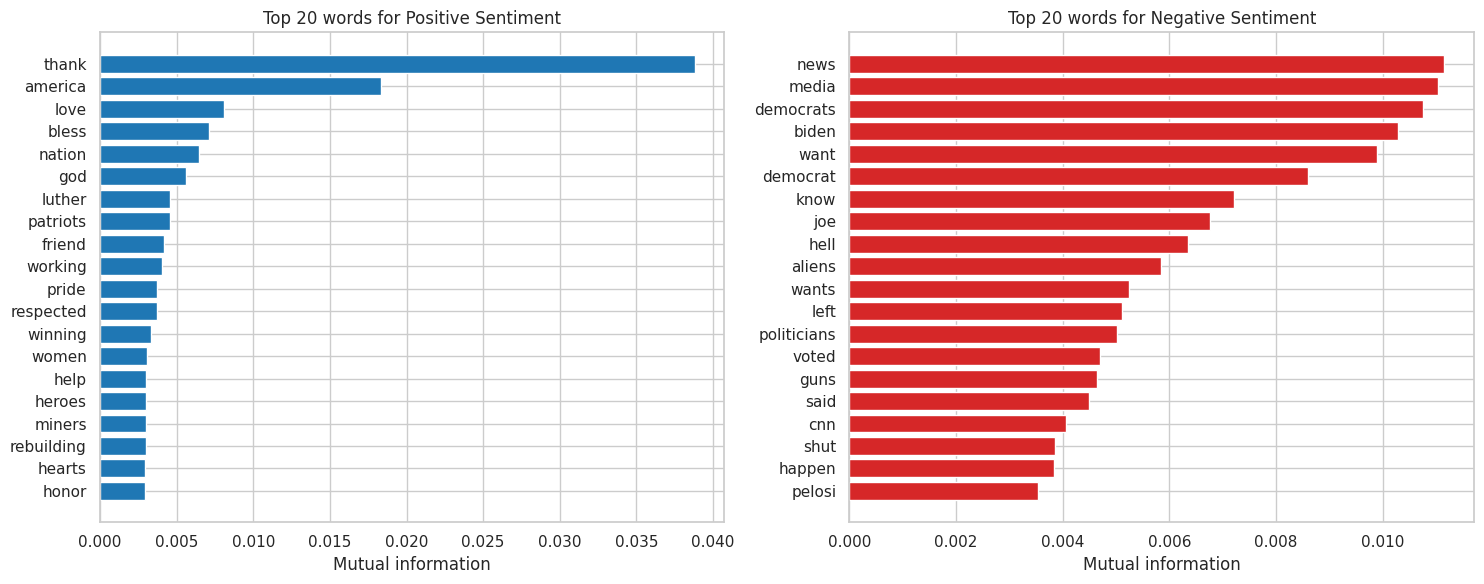

In [11]:
from sklearn.feature_selection import mutual_info_classif, chi2

# share of positive phrases each word shows up in
def word_direction(X, y):
    y = np.asarray(y, dtype=float)
    doc_freq = np.asarray(X.sum(axis=0)).ravel()
    pos = np.asarray(X.T @ y).ravel()
    return pos / np.maximum(doc_freq, 1)

def plot_two(pos, neg, title_pos, title_neg, xlabel):
    h = max(6, 0.28 * max(len(pos), len(neg)))
    fig, axes = plt.subplots(1, 2, figsize=(15, h))
    for ax, feats, color, title in ((axes[0], pos, "tab:blue", title_pos), (axes[1], neg, "tab:red", title_neg)):
        if feats:
            w, s = zip(*feats)
            ax.barh(w, s, color=color)
            ax.invert_yaxis()
        ax.set_title(title); ax.set_xlabel(xlabel)
    plt.tight_layout(); plt.show()

y = df1["label"].values
base_rate = y.mean()

cv_bin = CountVectorizer(binary=True, max_features=1000, min_df=3)
X = cv_bin.fit_transform(df1["Filtered_phrase"])
names = cv_bin.get_feature_names_out()
mi = mutual_info_classif(X, y, discrete_features=True, random_state=SEED)
direction = word_direction(X, y)

top_pos = sorted([(n, s) for n, s, d in zip(names, mi, direction) if d > base_rate], key=lambda x: x[1], reverse=True)[:20]
top_neg = sorted([(n, s) for n, s, d in zip(names, mi, direction) if d < base_rate], key=lambda x: x[1], reverse=True)[:20]
plot_two(top_pos, top_neg, "Top 20 words for Positive Sentiment", "Top 20 words for Negative Sentiment", "Mutual information")

## 9. Feature Importance for Sentiment — Chi-Square Test
Same idea with the original domain-specific stopword list removed first. (Fix: `chi2` is now imported.)

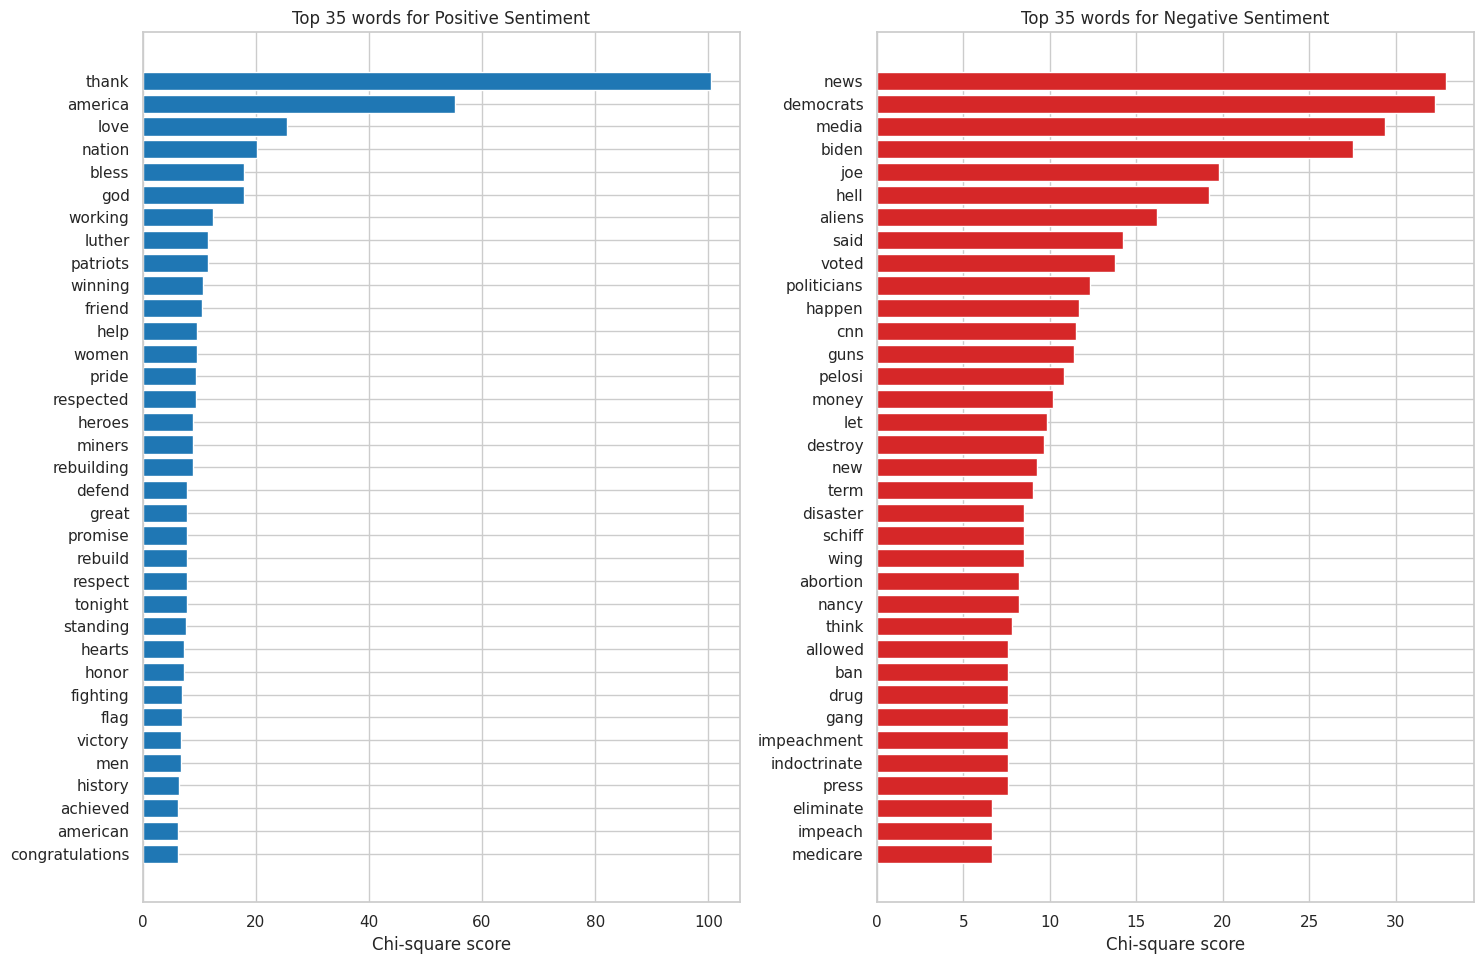

In [12]:
DOMAIN_STOP = {'know', 'want', 'wants', 'supports', 'crooked', 'party', 'straight', 'saw', 'moment',
               'left', 'guys', 'happened', 'idea', 'leader', 'lou', 'lies', 'gets', 'democrat',
               'trying', 'made', 'keep', 'need', 'telling', 'call', 'shut'}

phr = df1["Filtered_phrase"].apply(lambda p: " ".join(w for w in p.split() if w not in DOMAIN_STOP))
cv_chi = CountVectorizer(binary=True, max_features=1000, min_df=3)
X2 = cv_chi.fit_transform(phr)
names2 = cv_chi.get_feature_names_out()
chi2_scores, p_values = chi2(X2, y)
direction2 = word_direction(X2, y)

top_pos = sorted([(n, s) for n, s, d in zip(names2, chi2_scores, direction2) if d > base_rate], key=lambda x: x[1], reverse=True)[:35]
top_neg = sorted([(n, s) for n, s, d in zip(names2, chi2_scores, direction2) if d < base_rate], key=lambda x: x[1], reverse=True)[:35]
plot_two(top_pos, top_neg, "Top 35 words for Positive Sentiment", "Top 35 words for Negative Sentiment", "Chi-square score")

## 10. Extracting Biden-Related Sentences
Keeps every sentence mentioning Biden (bracketed stage directions removed), along with the rally date for the topics-over-time plot. "Joe" only counts when it is **not** followed by another surname (so "Joe Manchin", "Joe Rogan", ... are no longer pulled in).

In [13]:
BIDEN_RE = re.compile(r"\bbiden\b|\bsleepy\s+joe\b", re.I)
# "Joe" on its own (or "Joe Biden"), but not "Joe Manchin", "Joe Rogan", ... (case-sensitive on purpose)
JOE_RE = re.compile(r"\b[Jj]oe\b(?!\s+(?!Biden\b)[A-Z][a-z]+)")

all_biden_sentences, biden_dates = [], []
for i, tr in enumerate(texts):
    for s in SENT_SPLIT.split(TAG_RE.sub(" ", tr)):
        s = re.sub(r"\s+", " ", s).strip()
        if BIDEN_RE.search(s) or JOE_RE.search(s):
            all_biden_sentences.append(s)
            biden_dates.append(df.loc[i, "Date_parsed"])

print(len(all_biden_sentences), "sentences\n")
print("\n".join(all_biden_sentences[:10]))

826 sentences

You know our competitor, sleepy Joe, he had a rally today and practically nobody showed up.
Sleepy Joe, but it's great to be back in my home state, Florida to make my official return to the campaign trail.
Sleepy Joe Biden, not a nice guy, by the way, I have to be honest.
No, Biden had a bad day.
Now Biden had a bad day.
Joe Biden is also owned by the radical globalists, the wealthy donors, the big money special interests who shipped away your jobs, shut down your factories, threw open your borders, and ravaged your cities while sacrificing American blood and treasure in this ridiculous -- endless wars, set of endless wars that we've been in for a long time, 19 years.
Biden has made a corrupt bargain exchange for his party's nomination, he's handed control to the Socialists, the Marxists, and the left-wing extremists and you know that and he's got no strength left, he's got no power left.
Sleepy Joe wants to quadruple your taxes, you know, wants to quadruple.
And by the 

## 11. Topic Modeling Preparation
- **Masked sentences for the embeddings (kept from v4).** Every sentence mentions Biden, so "Biden", "Joe", "Sleepy Joe", "Biden's" ... are replaced by *he / his* and filler ("you know", "by the way") is removed. The encoder then has to use the subject of the sentence.
- **Content words for the topic words (changed).** spaCy **lemmas** of nouns, **proper nouns**, verbs, adjectives and adverbs, minus stopwords, names/nicknames and rally filler. Lemmas merge "win/wins" and "tax/taxes"; proper nouns make "China", "Ukraine", "Hunter", "NAFTA" possible topic words (v4 dropped them). Edit `FILLER_STOP` freely.
- **Content-free sentences are dropped** (fewer than `MIN_CONTENT_WORDS` content words), as in v4.
- `DOCS` (lemmas) → topic words, `DOCS_EMB` (masked) → embeddings, `DOCS_ORIG` (untouched) → display, sentiment and summaries. `DOC_TERMS` holds each sentence's words *and* adjacent two-word phrases, so keywords such as "law enforcement" can be matched as phrases.

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# the subject and his nicknames: every sentence is about him, so they carry no topic
NAME_STOP = {"joe", "biden", "sleepy", "slow", "crooked", "creepy", "trump", "donald"}
# rally filler, light verbs and words that occur in almost every topic of a rally speech (edit freely)
FILLER_STOP = {
    "say", "think", "get", "let", "like", "do", "go", "gon", "remember", "know", "want", "look", "tell",
    "thing", "people", "right", "can", "have", "need", "just", "now", "then", "here", "so", "way",
    "okay", "ok", "yeah", "lot", "mean", "come", "great", "fine", "guy", "folk", "everybody", "somebody",
    "anybody", "nobody", "really", "actually", "probably", "totally", "absolutely", "maybe", "believe",
    "happen", "make", "take", "give", "put", "talk", "call", "keep", "hear", "see", "try", "start",
    "bad", "good", "day", "month", "compare", "sir", "wow", "whatever", "hell", "thank",
    "america", "american", "country"}
CUSTOM_STOP = NAME_STOP | FILLER_STOP
KEEP_POS = {"NOUN", "PROPN", "VERB", "ADJ", "ADV"}

def content_lemmas(doc):
    """Lower-cased lemmas of content words (same function for the sentences and the reference corpus)."""
    out = []
    for t in doc:
        if not t.is_alpha or t.is_stop or t.pos_ not in KEEP_POS:
            continue
        lem = t.lemma_.lower()
        if len(lem) > 1 and lem not in CUSTOM_STOP and lem not in ENGLISH_STOP_WORDS:
            out.append(lem)
    return out

# --- text for the EMBEDDINGS: original sentence with the name/nicknames neutralised -------------
_NICK = r"(?:(?:sleepy|slow|crooked|creepy)\s+)?"
NAME_POSS_RE = re.compile(rf"\b{_NICK}(?:joe\s+)?biden['’]s\b|\b{_NICK}joe['’]s\b", re.I)
NAME_RE      = re.compile(rf"\b{_NICK}(?:joe\s+)?biden\b|\b{_NICK}joe\b", re.I)
FILLER_RE    = re.compile(r"\b(?:you know|by the way|believe me|let me tell you|I have to be honest|OK|okay)\b[,.]?\s*", re.I)

def mask_name(s):
    s = NAME_POSS_RE.sub("his", s)
    s = NAME_RE.sub("he", s)
    s = FILLER_RE.sub("", s)
    s = re.sub(r"\s*--\s*", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\s+([,.?!])", r"\1", s)
    s = re.sub(r",\s*([.?!])", r"\1", s).strip(" ,")
    return s[:1].upper() + s[1:]

def doc_terms(text, n_max=3):
    """Words of a cleaned sentence plus its adjacent n-grams, for phrase-aware keyword matching."""
    toks = text.split()
    terms = set(toks)
    for n in range(2, n_max + 1):
        terms |= {" ".join(toks[k:k + n]) for k in range(len(toks) - n + 1)}
    return terms

t0 = time.time()
cleaned_all = [" ".join(content_lemmas(d)) for d in nlp.pipe(all_biden_sentences, batch_size=64)]
keep = [i for i, c in enumerate(cleaned_all) if len(c.split()) >= MIN_CONTENT_WORDS]
DOCS       = [cleaned_all[i] for i in keep]                         # topic words (c-TF-IDF)
DOCS_ORIG  = [all_biden_sentences[i] for i in keep]                 # display, sentiment, summaries
DOCS_EMB   = [mask_name(all_biden_sentences[i]) for i in keep]      # embeddings (name masked)
DOCS_DATES = [biden_dates[i] for i in keep]
DOC_TERMS  = [doc_terms(d) for d in DOCS]
print(f"{len(DOCS)} of {len(cleaned_all)} sentences kept for topic modeling ({time.time() - t0:.0f}s)\n")
for o, m, c in list(zip(DOCS_ORIG, DOCS_EMB, DOCS))[:4]:
    print("original:", o, "\nembedded:", m, "\nwords:   ", c, "\n")

548 of 826 sentences kept for topic modeling (3s)

original: You know our competitor, sleepy Joe, he had a rally today and practically nobody showed up. 
embedded: Our competitor, he, he had a rally today and practically nobody showed up. 
words:    competitor rally today practically 

original: Sleepy Joe, but it's great to be back in my home state, Florida to make my official return to the campaign trail. 
embedded: He, but it's great to be back in my home state, Florida to make my official return to the campaign trail. 
words:    home state florida official return campaign trail 

original: Joe Biden is also owned by the radical globalists, the wealthy donors, the big money special interests who shipped away your jobs, shut down your factories, threw open your borders, and ravaged your cities while sacrificing American blood and treasure in this ridiculous -- endless wars, set of endless wars that we've been in for a long time, 19 years. 
embedded: He is also owned by the radical gl

In [15]:
class Coherence:
    """c_v / c_npmi topic coherence over a tokenised reference corpus (boolean sliding windows).
    Terms may be n-grams ("law enforcement"): an n-gram is present in a window if it starts there."""
    def __init__(self, token_docs, window, stride=1, cache_size=1500):
        vocab, ids, doc_of, starts, ends, offset = {}, [], [], [], [], 0
        for d, toks in enumerate(token_docs):
            L = len(toks)
            if L == 0:
                continue
            ids.extend(vocab.setdefault(w, len(vocab)) for w in toks)
            doc_of.extend([d] * L)
            s = np.array([0]) if L <= window else np.arange(0, L - window + 1, stride)
            if L > window and s[-1] != L - window:          # make sure the end of the text is covered
                s = np.append(s, L - window)
            starts.append(s + offset)
            ends.append(np.minimum(s + window, L) + offset)
            offset += L
        self.ids, self.doc_of = np.asarray(ids), np.asarray(doc_of)
        self.order = np.argsort(self.ids, kind="stable")          # token positions grouped by word id
        self.bounds = np.searchsorted(self.ids[self.order], np.arange(len(vocab) + 1))
        self.vocab, self.starts, self.ends = vocab, np.concatenate(starts), np.concatenate(ends)
        self.n = len(self.starts)
        self._cache, self._cache_size = {}, cache_size

    def _positions(self, term):
        parts = term.split()
        wid = self.vocab.get(parts[0])
        if wid is None:
            return None
        pos = self.order[self.bounds[wid]:self.bounds[wid + 1]]
        for k, w in enumerate(parts[1:], start=1):              # n-gram: following tokens must match
            wk = self.vocab.get(w)
            if wk is None:
                return None
            pos = pos[pos + k < len(self.ids)]
            pos = pos[(self.ids[pos + k] == wk) & (self.doc_of[pos + k] == self.doc_of[pos])]
        return pos

    def presence(self, term):
        if term in self._cache:
            return self._cache[term]
        pos = self._positions(term)
        v = None if pos is None or len(pos) == 0 else \
            (np.searchsorted(pos, self.ends) - np.searchsorted(pos, self.starts)) > 0
        if len(self._cache) < self._cache_size:
            self._cache[term] = v
        return v

    def score_topic(self, words, measure="c_v"):
        P = [self.presence(w) for w in words]
        P = [p for p in P if p is not None and p.any()]
        if len(P) < 2:
            return np.nan
        M = np.vstack(P).astype(np.float64)
        p = M.mean(axis=1)
        joint = (M @ M.T) / self.n
        eps = 1e-12
        # guard: a pair present in every window has joint = 1 -> 0/0; count it as 0 (no information)
        npmi = np.log((joint + eps) / np.outer(p, p)) / np.maximum(-np.log(joint + eps), 1e-9)
        if measure == "c_v":
            s = npmi.sum(axis=0)
            cos = (npmi @ s) / (np.linalg.norm(npmi, axis=1) * np.linalg.norm(s) + eps)
            return float(cos.mean())
        iu = np.triu_indices(len(P), k=1)
        return float(npmi[iu].mean())

# reference corpus = all full transcripts, processed with exactly the same content_lemmas() as the sentences
t0 = time.time()
_ref_disable = [p for p in ("parser", "ner") if p in nlp.pipe_names]
with nlp.select_pipes(disable=_ref_disable):
    ref_docs = [content_lemmas(d) for d in nlp.pipe((TAG_RE.sub(" ", t) for t in texts), batch_size=2)]
CV = Coherence(ref_docs, window=110, stride=10)   # c_v   (stride 10 keeps memory low; near-identical to stride 1)
NP = Coherence(ref_docs, window=10, stride=5)     # c_npmi
print(f"Reference corpus: {sum(map(len, ref_docs)):,} content lemmas in {time.time() - t0:.0f}s | "
      f"c_v windows: {CV.n:,} | npmi windows: {NP.n:,}")
print("Sanity check  c_v(tax, cut, income, raise, increase) =",
      round(CV.score_topic(["tax", "cut", "income", "raise", "increase"]), 3))
print("              c_v(tax, military, beautiful, china, vote) =",
      round(CV.score_topic(["tax", "military", "beautiful", "china", "vote"]), 3))
print("              phrase 'law enforcement' found in", int(CV.presence("law enforcement").sum())
      if CV.presence("law enforcement") is not None else 0, "c_v windows")

Reference corpus: 255,195 content lemmas in 80s | c_v windows: 24,535 | npmi windows: 50,974
Sanity check  c_v(tax, cut, income, raise, increase) = 0.757
              c_v(tax, military, beautiful, china, vote) = 0.397
              phrase 'law enforcement' found in 2544 c_v windows


### 11.1 Sentence embeddings (computed once, reused by every experiment)
Four free sentence-transformer models × two inputs: the **masked sentence** (default) and the **cleaned lemmas** (bag of words). The bag-of-words input is still scored in Stage A so you can see the difference, but it is not eligible for the final model unless `ALLOW_LEXICAL_EMBEDDINGS = True`: clustering on shared words is exactly what a keyword-based score rewards, so letting it win would be circular.

In [16]:
from sentence_transformers import SentenceTransformer

EMB_MODELS = {
    "mpnet":     "sentence-transformers/all-mpnet-base-v2",
    "minilm":    "sentence-transformers/all-MiniLM-L6-v2",
    "bge-small": "BAAI/bge-small-en-v1.5",
    "bge-base":  "BAAI/bge-base-en-v1.5",
}
ST, EMB = {}, {}
t0 = time.time()
for short, name in EMB_MODELS.items():
    with quiet():
        ST[short] = SentenceTransformer(name, device=TORCH_DEVICE)
    for inp, data in (("masked", DOCS_EMB), ("cleaned", DOCS)):
        EMB[f"{short}|{inp}"] = np.asarray(ST[short].encode(data, batch_size=64, show_progress_bar=False,
                                                            normalize_embeddings=True))
print(f"{len(EMB)} embedding sets in {time.time() - t0:.0f}s:", list(EMB))

8 embedding sets in 28s: ['mpnet|masked', 'mpnet|cleaned', 'minilm|masked', 'minilm|cleaned', 'bge-small|masked', 'bge-small|cleaned', 'bge-base|masked', 'bge-base|cleaned']


### 11.2 Collapse near-duplicate sentences
Rally speeches reuse the same lines word for word. HDBSCAN treats ten copies of one sentence as the densest possible "cluster", which is how v4 ended up with topics such as "If Biden wins, the mob wins". Here each group of near-identical sentences (cosine ≥ `DEDUP_THRESHOLD` on the masked mpnet embeddings) is represented by its first occurrence for **clustering and scoring**. Every repeat keeps its place in the data: after the model is fitted, repeats inherit the topic of their representative, so topic sizes ("mentions"), sentiment and the time trends still count how often something was said.

Check the two lists printed below: if the *merged* pairs are not really the same line, raise the threshold; if the *kept separate* pairs are, lower it.

In [17]:
DEDUP_EMB = "mpnet|masked"
E_D = EMB[DEDUP_EMB]
reps, REP, BEST_SIM, BEST_REP = [], np.empty(len(DOCS), dtype=int), np.zeros(len(DOCS)), np.full(len(DOCS), -1)
for i in range(len(DOCS)):
    if reps:
        s = E_D[reps] @ E_D[i]
        j = int(np.argmax(s))
        BEST_SIM[i], BEST_REP[i] = s[j], reps[j]
        if s[j] >= DEDUP_THRESHOLD:
            REP[i] = reps[j]
            continue
    reps.append(i)
    REP[i] = i

UNIQ = np.asarray(reps)                                   # indices (into DOCS) of the representatives
U_POS = {int(d): k for k, d in enumerate(UNIQ)}            # DOCS index -> position among the unique sentences
DUP_COUNT_U = np.bincount([U_POS[int(r)] for r in REP], minlength=len(UNIQ))   # how often each line was said
DOCS_U      = [DOCS[i] for i in UNIQ]
DOCS_ORIG_U = [DOCS_ORIG[i] for i in UNIQ]
DOCS_EMB_U  = [DOCS_EMB[i] for i in UNIQ]
DOC_TERMS_U = [DOC_TERMS[i] for i in UNIQ]

def to_all(topics_u):
    """Topic of every sentence (repeats inherit the topic of their representative)."""
    topics_u = np.asarray(topics_u)
    return topics_u[[U_POS[int(r)] for r in REP]]

print(f"{len(DOCS)} sentences -> {len(UNIQ)} unique lines "
      f"({len(DOCS) - len(UNIQ)} repeats collapsed, threshold {DEDUP_THRESHOLD})\n")
print("Most repeated lines:")
for k in np.argsort(-DUP_COUNT_U)[:8]:
    if DUP_COUNT_U[k] > 1:
        print(f"  {DUP_COUNT_U[k]:>3}x  {textwrap.shorten(DOCS_ORIG_U[k], 110)}")

merged = [i for i in range(len(DOCS)) if REP[i] != i]
kept = [i for i in range(len(DOCS)) if REP[i] == i and BEST_REP[i] >= 0]
print("\nMerged pairs with the LOWEST similarity (should still be the same line):")
for i in sorted(merged, key=lambda i: BEST_SIM[i])[:4]:
    print(f"  {BEST_SIM[i]:.3f}  {textwrap.shorten(DOCS_ORIG[i], 70)}\n         ~ {textwrap.shorten(DOCS_ORIG[BEST_REP[i]], 70)}")
print("\nKept-separate pairs with the HIGHEST similarity (should be different lines):")
for i in sorted(kept, key=lambda i: -BEST_SIM[i])[:4]:
    print(f"  {BEST_SIM[i]:.3f}  {textwrap.shorten(DOCS_ORIG[i], 70)}\n         ~ {textwrap.shorten(DOCS_ORIG[BEST_REP[i]], 70)}")

548 sentences -> 511 unique lines (37 repeats collapsed, threshold 0.92)

Most repeated lines:
    6x  If Biden wins, China wins.
    4x  Biden voted for the Iraq war.
    4x  If Biden wins, the mob wins.
    4x  When I banned travel from China in January, Sleepy Joe Biden called it as hysterical, that's xenophobic.
    4x  The Biden plan would destroy Social Security and destroy protections for pre-existing conditions.
    3x  We spent the last four years, reversing the horrible damage Joe Biden inflicted over the last 47 years.
    3x  If Biden wins, the rioters win, the anarchists win, arsonists, flag burners, they all win.
    3x  Biden pledges to oppose school choice and he stated that if elected, charter schools are gone and [...]

Merged pairs with the LOWEST similarity (should still be the same line):
  0.923  Biden has even pledged to terminate our travel ban jihadist [...]
         ~ Biden has even pledged to terminate our travel ban on jihadist [...]
  0.928  The Biden agend

### 11.3 BERTopic experiment helpers
**The score.** For every topic, take its top `COVERAGE_TOPN` terms and mark which unique sentences contain at least one of them.
- *Recall* = share of the topic's own sentences that contain its terms (v4's "coverage").
- *Precision* = share of all sentences containing those terms that belong to the topic. Generic words ("vote", "year") appear everywhere, so they get low precision.
- *Keyword F1* = harmonic mean of the two, size-weighted over topics.

`fit = coherence × keyword F1 × assigned share`, where coherence is c_v (or rescaled c_npmi, see `COHERENCE_MEASURE`) of the top-10 terms against the full transcripts, and *assigned share* = 1 − share of unique sentences left in the outlier topic. A configuration is **valid** if it has `MIN_TOPICS`–`MAX_TOPICS` topics and at most `MAX_OUTLIER_SHARE` unassigned, on at least half of the seeds.

**Other fixes in the model itself**
- `min_df=1`: BERTopic fits the vectorizer on one concatenated document *per topic*, so v4's `min_df=2` removed every word that occurred in only one topic, which are exactly the most distinctive words.
- `top_n_words=20`, then a term is skipped if it shares a word with a higher-ranked term, so "far left" and "left" never count as two pieces of evidence.
- Outlier reassignment: an unassigned sentence joins the topic whose centroid is most similar, if the cosine similarity is at least `outlier_threshold`; the topic words are then recomputed.

In [18]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

TOP_N_WORDS = 20
FIT_LABEL = f"fit = {COHERENCE_MEASURE} × keyword F1 × assigned share"
BASE_CFG = dict(emb="mpnet|masked", n_neighbors=15, n_components=5, min_cluster_size=10, min_samples=None,
                method="eom", ngram_max=1, reduce_frequent_words=False, bm25=False, nr_topics=None,
                outlier_threshold=0.4, zs_min_sim=None)
ELIGIBLE_EMB = [k for k in EMB if ALLOW_LEXICAL_EMBEDDINGS or k.endswith("|masked")]

# guided topics for Stage H: short title -> description that is embedded (edit freely)
ZEROSHOT_TOPICS = {
    "Radical left, riots & policing":   "the radical left, riots, mobs, defunding the police and law and order",
    "Trade, jobs & China":              "trade deals, outsourcing factories and jobs, and China",
    "Taxes, energy & the economy":      "tax increases, banning fracking and oil, energy and the economy",
    "Immigration & the travel ban":     "illegal immigration, open borders, refugees and the travel ban",
    "COVID, lockdowns & the vaccine":   "the coronavirus pandemic, lockdowns, the vaccine and reopening",
    "Hunter Biden & Ukraine":           "Hunter Biden, Ukraine, China money and family corruption",
    "47-year political record":         "his 47 years in politics, his record and past failures",
    "Mental decline & weakness":        "mental decline, weakness, the basement and being controlled by others",
    "Guns & the Second Amendment":      "taking away guns and the Second Amendment",
    "Endless wars & the military":      "endless foreign wars, the military and troops",
}

LOG, _WARNED = [], set()
NUM_KEYS = ["fit", "c_v", "c_npmi", "kw_f1", "recall", "precision", "assigned", "outlier_pct", "n_topics", "diversity"]

def warn_once(key, msg):
    if key not in _WARNED:
        _WARNED.add(key)
        print("  note:", msg)

def nmean(v):
    v = np.asarray([np.nan if x is None else x for x in v], dtype=float)
    return float(np.nanmean(v)) if np.isfinite(v).any() else np.nan

def _is_none(x):
    return x is None or (isinstance(x, float) and np.isnan(x))

def build_model(c, seed, representation_model=None, embedding_model=None):
    ms = c.get("min_samples")
    extra = {}
    if not _is_none(c.get("zs_min_sim")):
        extra = dict(zeroshot_topic_list=list(ZEROSHOT_TOPICS.values()),
                     zeroshot_min_similarity=float(c["zs_min_sim"]))
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=int(c["n_neighbors"]), n_components=int(c["n_components"]),
                        min_dist=0.0, metric="cosine", random_state=int(seed)),
        hdbscan_model=HDBSCAN(min_cluster_size=int(c["min_cluster_size"]),
                              min_samples=None if _is_none(ms) else int(ms),
                              metric="euclidean", cluster_selection_method=c["method"], prediction_data=True),
        vectorizer_model=CountVectorizer(ngram_range=(1, int(c["ngram_max"])), min_df=1,
                                         token_pattern=r"(?u)\b[a-z][a-z]+\b"),
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=bool(c["reduce_frequent_words"]),
                                           bm25_weighting=bool(c["bm25"])),
        representation_model=representation_model,
        nr_topics=None if _is_none(c["nr_topics"]) else c["nr_topics"],
        top_n_words=TOP_N_WORDS, verbose=False, **extra)

def topic_terms(model, aspect=None, topn=10):
    """Top terms per topic, skipping any term that shares a word with a higher-ranked term."""
    raw = model.get_topics() if aspect is None else getattr(model, "topic_aspects_", {}).get(aspect, {})
    out = {}
    for tid, ws in raw.items():
        if tid == -1:
            continue
        picked, used = [], set()
        for w in ws:
            term = str(w[0] if isinstance(w, (tuple, list)) else w).strip().lower()
            toks = term.split()
            if not toks or used & set(toks):
                continue
            picked.append(term)
            used |= set(toks)
            if len(picked) == topn:
                break
        if picked:
            out[tid] = picked
    return out

def reassign_outliers(model, E, threshold, representation_model=None):
    """Move an outlier to the most similar topic centroid if cosine >= threshold; recompute topic words."""
    topics = np.asarray(model.topics_)
    if _is_none(threshold) or not (topics == -1).any():
        return topics
    ids = sorted(t for t in set(topics.tolist()) if t != -1)
    if not ids:
        return topics
    En = E / np.linalg.norm(E, axis=1, keepdims=True).clip(1e-12)
    cents = np.vstack([En[topics == t].mean(axis=0) for t in ids])
    cents /= np.linalg.norm(cents, axis=1, keepdims=True).clip(1e-12)
    out = np.where(topics == -1)[0]
    sim = En[out] @ cents.T
    ok = sim.max(axis=1) >= threshold
    if not ok.any():
        return topics
    new = topics.copy()
    new[out[ok]] = np.asarray(ids)[sim.argmax(axis=1)[ok]]
    try:
        model.update_topics(DOCS_U, topics=new.tolist(), top_n_words=TOP_N_WORDS,
                            vectorizer_model=model.vectorizer_model, ctfidf_model=model.ctfidf_model,
                            representation_model=representation_model)
        if hasattr(model, "_outliers") and not isinstance(getattr(type(model), "_outliers", None), property):
            model._outliers = 1 if -1 in set(model.topics_) else 0   # older BERTopic: keep the outlier flag consistent
    except Exception as ex:
        warn_once("update_topics", f"update_topics failed ({ex}); outliers are left unassigned.")
        return topics
    return np.asarray(model.topics_)

def evaluate(model, aspect=None):
    topics = np.asarray(model.topics_)
    tw = topic_terms(model, aspect, topn=10)
    ids = sorted(t for t in set(topics.tolist()) if t != -1)
    sizes = {t: int((topics == t).sum()) for t in ids}
    per = {}
    for t in ids:
        words = tw.get(t, [])
        top = set(words[:COVERAGE_TOPN])
        hit = np.fromiter((bool(s & top) for s in DOC_TERMS_U), dtype=bool, count=len(DOC_TERMS_U))
        inside = topics == t
        r = float(hit[inside].mean()) if inside.any() else 0.0
        p = float((hit & inside).sum() / hit.sum()) if hit.any() else 0.0
        per[t] = dict(words=words, size=sizes[t],
                      c_v=CV.score_topic(words, "c_v") if len(words) >= 2 else np.nan,
                      c_npmi=NP.score_topic(words, "c_npmi") if len(words) >= 2 else np.nan,
                      recall=r, precision=p, f1=2 * p * r / (p + r) if p + r > 0 else 0.0)
    tot = sum(sizes.values())
    wmean = lambda k: sum(per[t][k] * sizes[t] for t in ids) / tot if tot else np.nan
    all_words = [w for t in ids for term in per[t]["words"] for w in term.split()]
    m = dict(n_topics=len(ids),
             c_v=nmean([per[t]["c_v"] for t in ids]), c_npmi=nmean([per[t]["c_npmi"] for t in ids]),
             recall=wmean("recall"), precision=wmean("precision"), kw_f1=wmean("f1"),
             outlier_pct=float(np.mean(topics == -1)),
             diversity=len(set(all_words)) / max(1, len(all_words)), per_topic=per)
    m["assigned"] = 1.0 - m["outlier_pct"]
    coh = m["c_v"] if COHERENCE_MEASURE == "c_v" else (m["c_npmi"] + 1) / 2
    m["fit"] = coh * m["kw_f1"] * m["assigned"]
    m["valid"] = bool(MIN_TOPICS <= m["n_topics"] <= MAX_TOPICS and m["outlier_pct"] <= MAX_OUTLIER_SHARE
                      and np.isfinite(m["fit"]))
    return m

def fit_once(cfg, seed, representation_model=None, embedding_model=None):
    E = EMB[cfg["emb"]][UNIQ]
    if embedding_model is None and not _is_none(cfg.get("zs_min_sim")):
        embedding_model = ST[cfg["emb"].split("|")[0]]          # zero-shot needs the model to embed topic names
    model = build_model(cfg, seed, representation_model, embedding_model)
    model.fit(DOCS_U, embeddings=E)
    reassign_outliers(model, E, cfg.get("outlier_threshold"), representation_model)
    return model

def run_config(overrides, stage, base=None, seeds=None, keep_model=False, verbose=True, tag=""):
    cfg = {**BASE_CFG, **(base or {}), **overrides}
    seeds = list(SEARCH_SEEDS if seeds is None else seeds)
    per, kept, t0 = [], None, time.time()
    for s in seeds:
        try:
            model = fit_once(cfg, s)
            m = evaluate(model)
            m["topics_u"] = np.asarray(model.topics_)
            if keep_model and kept is None:
                kept = model
        except Exception as e:
            print(f"  [{stage}{tag}] seed {s} failed: {e}")
            m = {k: np.nan for k in NUM_KEYS}
            m.update(valid=False, topics_u=None)
        per.append(m)
    fits = np.array([m["fit"] for m in per], dtype=float)
    n_valid = sum(bool(m.get("valid")) for m in per)
    rec = {"stage": stage, "cfg": dict(cfg), **cfg, "seeds": seeds, "fits": fits.tolist(),
           **{k: nmean([m.get(k) for m in per]) for k in NUM_KEYS},
           "fit_std": float(np.nanstd(fits)) if np.isfinite(fits).any() else np.nan,
           "n_valid": n_valid, "seconds": time.time() - t0,
           "topics_by_seed": [m.get("topics_u") for m in per]}
    rec["score"] = rec["fit"] if (2 * n_valid >= len(seeds) and np.isfinite(rec["fit"])) else np.nan
    rec["eligible"] = bool(ALLOW_LEXICAL_EMBEDDINGS or cfg["emb"].endswith("|masked"))
    LOG.append(rec)
    if verbose:
        flag = "" if np.isfinite(rec["score"]) else "  (fails constraints)"
        flag += "" if rec["eligible"] else "  [reference only]"
        print(f"  [{stage}{tag}] fit={rec['fit']:.3f}±{rec['fit_std']:.3f}  c_v={rec['c_v']:.3f}  "
              f"kwF1={rec['kw_f1']:.2f} (P {rec['precision']:.2f}/R {rec['recall']:.2f})  "
              f"assigned={rec['assigned']:.0%}  topics={rec['n_topics']:.1f}{flag}")
    return kept, rec

def best_record(stages=None, exclude=("I Stability",), eligible_only=True):
    recs = [r for r in LOG if (stages is None or r["stage"] in stages) and r["stage"] not in exclude
            and (r["eligible"] or not eligible_only)]
    pool = [r for r in recs if np.isfinite(r["score"])] or [r for r in recs if np.isfinite(r["fit"])]
    if not pool:
        raise RuntimeError(f"No successful BERTopic fit in stages {stages}.")
    return max(pool, key=lambda r: r["score"] if np.isfinite(r["score"]) else r["fit"])

def stage_df(stage):
    return pd.DataFrame([{k: v for k, v in r.items() if k not in ("cfg", "topics_by_seed")}
                         for r in LOG if r["stage"] == stage])

def plot_components(ax, x, d, xlabel, title="components of the fit (mean over seeds)"):
    for col, style, lab in (("c_v", "o--", "c_v"), ("kw_f1", "s--", "keyword F1"),
                            ("precision", "v:", "keyword precision"), ("recall", "^:", "keyword recall"),
                            ("assigned", "D-", "assigned share")):
        ax.plot(x, d[col], style, label=lab)
    ax.set_ylim(0, 1.02); ax.set_xlabel(xlabel); ax.set_title(title); ax.legend(fontsize=8, loc="lower left")

## 12. BERTopic Optimisation (target: coherence × keyword F1 × assigned share)

Stages A–F are a **coordinate-descent** search: each stage tunes one group of settings and passes its winner on. Stage G runs a **joint search** over everything, comparing **Random search** with **Bayesian optimisation (Optuna TPE)**. Stage H tries **guided (zero-shot) topics**. Stage I checks the overall winner on five *new* seeds.

Every point is the **mean over `SEARCH_SEEDS`** (error bars = sd across seeds). Differences smaller than the error bars are noise. The left panels plot the **fit**; the right panels show its **components** (c_v, keyword precision/recall/F1, assigned share), so you can see *why* the fit moves.

### Baseline — the original notebook's setup
`all-mpnet-base-v2` on the bag-of-words text, no outlier reassignment, scored with the new metric. Shown for reference only.

In [19]:
_, baseline = run_config({"emb": "mpnet|cleaned", "outlier_threshold": None}, stage="0 Baseline")

  [0 Baseline] fit=0.213±0.013  c_v=0.500  kwF1=0.60 (P 0.60/R 0.69)  assigned=71%  topics=10.7  [reference only]


### Stage A — embedding model & input text
Hatched bars use the bag-of-words input and are shown for reference only (see 11.1).

  [A Embedding mpnet|masked] fit=0.271±0.012  c_v=0.525  kwF1=0.55 (P 0.62/R 0.53)  assigned=94%  topics=7.7
  [A Embedding mpnet|cleaned] fit=0.264±0.017  c_v=0.493  kwF1=0.62 (P 0.65/R 0.66)  assigned=87%  topics=10.7  [reference only]
  [A Embedding minilm|masked] fit=0.231±0.048  c_v=0.433  kwF1=0.55 (P 0.78/R 0.47)  assigned=97%  topics=5.3
  [A Embedding minilm|cleaned] fit=0.285±0.008  c_v=0.549  kwF1=0.65 (P 0.69/R 0.69)  assigned=80%  topics=10.7  [reference only]
  [A Embedding bge-small|masked] fit=0.252±0.039  c_v=0.500  kwF1=0.50 (P 0.72/R 0.46)  assigned=100%  topics=7.3
  [A Embedding bge-small|cleaned] fit=0.275±0.041  c_v=0.510  kwF1=0.54 (P 0.72/R 0.50)  assigned=100%  topics=7.7  [reference only]
  [A Embedding bge-base|masked] fit=0.238±0.023  c_v=0.518  kwF1=0.46 (P 0.75/R 0.43)  assigned=100%  topics=7.3
  [A Embedding bge-base|cleaned] fit=0.301±0.009  c_v=0.520  kwF1=0.58 (P 0.68/R 0.57)  assigned=100%  topics=10.3  [reference only]


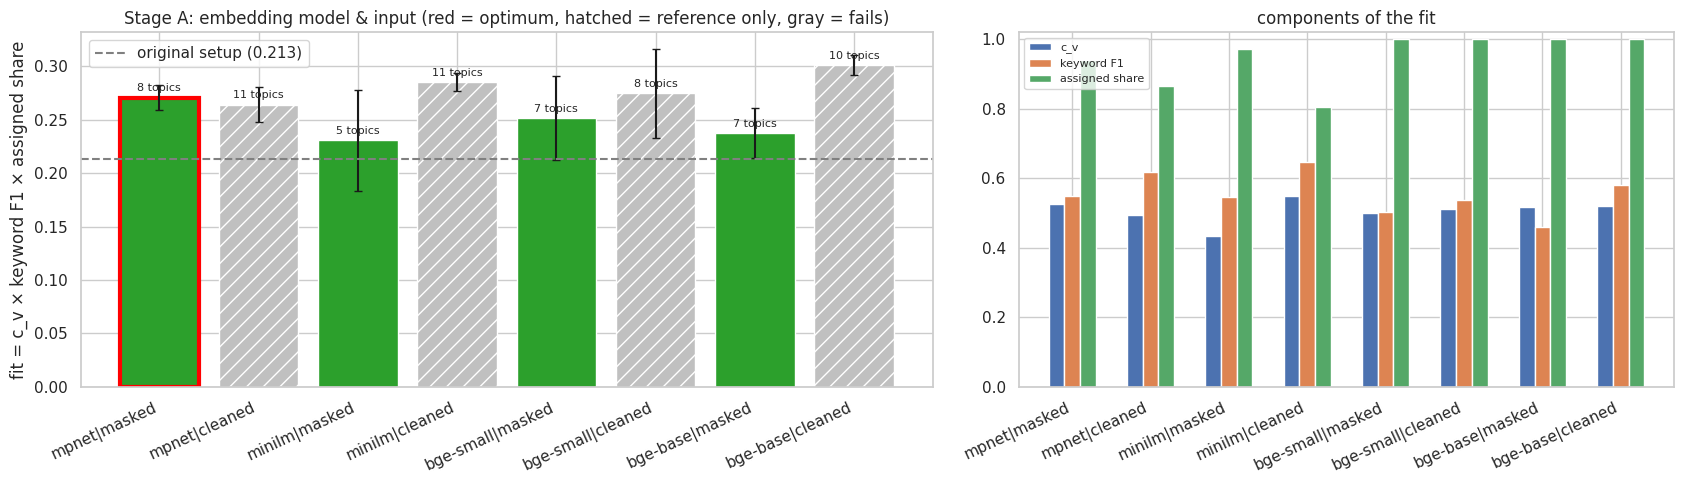

Best eligible embedding: mpnet|masked


In [20]:
for k in EMB:
    run_config({"emb": k}, stage="A Embedding", tag=f" {k}")

a = stage_df("A Embedding")
best_a = best_record(["A Embedding"])
fig, axes = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={"width_ratios": [1.3, 1]})
x = np.arange(len(a))
colors = ["lightgray" if not np.isfinite(s) else ("tab:green" if e else "silver") for s, e in zip(a["score"], a["eligible"])]
bars = axes[0].bar(x, np.nan_to_num(a["fit"]), yerr=np.nan_to_num(a["fit_std"]), color=colors, capsize=3)
for b, n_t, e, el in zip(bars, a["n_topics"], a["emb"], a["eligible"]):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.006, f"{n_t:.0f} topics", ha="center", fontsize=8)
    if not el:
        b.set_hatch("//")
    if e == best_a["emb"]:
        b.set_edgecolor("red"); b.set_linewidth(3)
axes[0].axhline(baseline["fit"], ls="--", color="gray", label=f"original setup ({baseline['fit']:.3f})")
axes[0].set_xticks(x); axes[0].set_xticklabels(a["emb"], rotation=25, ha="right")
axes[0].set_ylabel(FIT_LABEL); axes[0].legend()
axes[0].set_title("Stage A: embedding model & input (red = optimum, hatched = reference only, gray = fails)")
w = 0.2
for j, (col, lab) in enumerate((("c_v", "c_v"), ("kw_f1", "keyword F1"), ("assigned", "assigned share"))):
    axes[1].bar(x + (j - 1) * w, a[col], width=w, label=lab)
axes[1].set_xticks(x); axes[1].set_xticklabels(a["emb"], rotation=25, ha="right")
axes[1].set_ylim(0, 1.02); axes[1].legend(fontsize=8); axes[1].set_title("components of the fit")
plt.tight_layout(); plt.show()
print("Best eligible embedding:", best_a["emb"])

### Stage B — HDBSCAN `min_cluster_size`

  [B HDBSCAN min_cluster_size mcs=5] fit=0.252±0.004  c_v=0.497  kwF1=0.52 (P 0.48/R 0.64)  assigned=97%  topics=22.3
  [B HDBSCAN min_cluster_size mcs=8] fit=0.250±0.007  c_v=0.486  kwF1=0.55 (P 0.60/R 0.55)  assigned=94%  topics=10.0
  [B HDBSCAN min_cluster_size mcs=10] fit=0.271±0.012  c_v=0.525  kwF1=0.55 (P 0.62/R 0.53)  assigned=94%  topics=7.7
  [B HDBSCAN min_cluster_size mcs=12] fit=0.268±0.011  c_v=0.512  kwF1=0.56 (P 0.66/R 0.52)  assigned=94%  topics=7.0
  [B HDBSCAN min_cluster_size mcs=15] fit=0.301±0.006  c_v=0.556  kwF1=0.58 (P 0.72/R 0.51)  assigned=93%  topics=5.0  (fails constraints)
  [B HDBSCAN min_cluster_size mcs=20] fit=0.298±0.004  c_v=0.554  kwF1=0.58 (P 0.71/R 0.50)  assigned=93%  topics=5.0  (fails constraints)
  [B HDBSCAN min_cluster_size mcs=25] fit=0.258±0.012  c_v=0.509  kwF1=0.54 (P 0.77/R 0.45)  assigned=94%  topics=3.3  (fails constraints)
  [B HDBSCAN min_cluster_size mcs=30] fit=0.264±0.003  c_v=0.507  kwF1=0.56 (P 0.71/R 0.48)  assigned=92%  topi

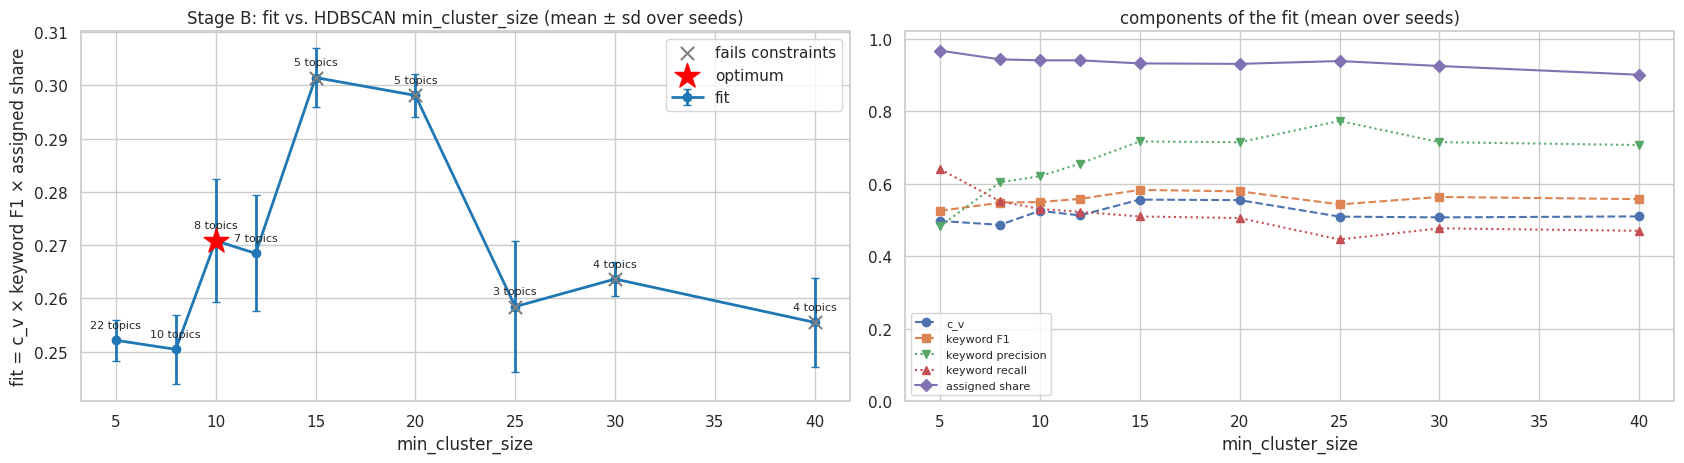

In [21]:
cur = best_a["cfg"]
for mcs in [5, 8, 10, 12, 15, 20, 25, 30, 40]:
    run_config({"min_cluster_size": mcs}, stage="B HDBSCAN min_cluster_size", base=cur, tag=f" mcs={mcs}")

b = stage_df("B HDBSCAN min_cluster_size").sort_values("min_cluster_size")
best_b = best_record(["B HDBSCAN min_cluster_size"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 4.8))
ax1.errorbar(b["min_cluster_size"], b["fit"], yerr=b["fit_std"], fmt="o-", color="tab:blue", lw=2, capsize=3, label="fit")
inv = b[b["score"].isna()]
ax1.scatter(inv["min_cluster_size"], inv["fit"], marker="x", s=90, color="gray", zorder=5, label="fails constraints")
ax1.scatter([best_b["min_cluster_size"]], [best_b["fit"]], marker="*", s=350, color="red", zorder=6, label="optimum")
for r in b.itertuples():
    ax1.annotate(f"{r.n_topics:.0f} topics", (r.min_cluster_size, r.fit), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8)
ax1.set_xlabel("min_cluster_size"); ax1.set_ylabel(FIT_LABEL); ax1.legend()
ax1.set_title("Stage B: fit vs. HDBSCAN min_cluster_size (mean ± sd over seeds)")
plot_components(ax2, b["min_cluster_size"], b, "min_cluster_size")
plt.tight_layout(); plt.show()

### Stage C — UMAP `n_neighbors` × `n_components`

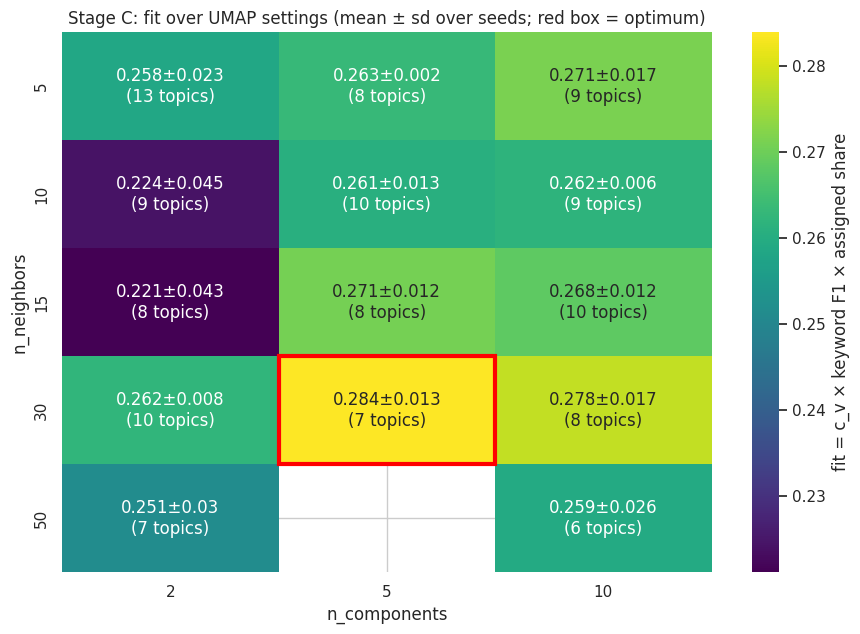

Best UMAP: n_neighbors=30, n_components=5, fit=0.284±0.013 (c_v 0.512, keyword F1 0.58, assigned 96%)


In [22]:
cur = best_b["cfg"]
for nn in [5, 10, 15, 30, 50]:
    for nc in [2, 5, 10]:
        run_config({"n_neighbors": nn, "n_components": nc}, stage="C UMAP grid", base=cur, verbose=False)

c = stage_df("C UMAP grid")
best_c = best_record(["C UMAP grid"])
piv = c.pivot_table(index="n_neighbors", columns="n_components", values="score", dropna=False)
piv_sd = c.pivot_table(index="n_neighbors", columns="n_components", values="fit_std", dropna=False)
piv_n = c.pivot_table(index="n_neighbors", columns="n_components", values="n_topics", dropna=False).fillna(0)
annot = (piv.round(3).astype(str) + "±" + piv_sd.round(3).astype(str) + "\n(" + piv_n.round(0).astype(int).astype(str) + " topics)")
annot = annot.where(piv.notna(), "fails")
plt.figure(figsize=(9, 6.5))
ax = sns.heatmap(piv, annot=annot, fmt="", cmap="viridis", cbar_kws={"label": FIT_LABEL})
r_i = list(piv.index).index(best_c["n_neighbors"]); c_i = list(piv.columns).index(best_c["n_components"])
ax.add_patch(plt.Rectangle((c_i, r_i), 1, 1, fill=False, edgecolor="red", lw=3))
ax.set_title("Stage C: fit over UMAP settings (mean ± sd over seeds; red box = optimum)")
plt.tight_layout(); plt.show()
print(f"Best UMAP: n_neighbors={best_c['n_neighbors']}, n_components={best_c['n_components']}, "
      f"fit={best_c['fit']:.3f}±{best_c['fit_std']:.3f} (c_v {best_c['c_v']:.3f}, keyword F1 {best_c['kw_f1']:.2f}, "
      f"assigned {best_c['assigned']:.0%})")

### Stage D — outlier reassignment threshold
`off` = HDBSCAN's outliers stay unassigned (v4 behaviour). Lower thresholds assign more sentences; keyword precision tells you when the added sentences no longer fit their topic.

  [D Outlier reassignment threshold=off] fit=0.241±0.010  c_v=0.534  kwF1=0.58 (P 0.62/R 0.57)  assigned=79%  topics=7.3
  [D Outlier reassignment threshold=0.6] fit=0.243±0.006  c_v=0.516  kwF1=0.57 (P 0.63/R 0.56)  assigned=82%  topics=7.3
  [D Outlier reassignment threshold=0.5] fit=0.279±0.006  c_v=0.525  kwF1=0.59 (P 0.67/R 0.55)  assigned=90%  topics=7.3
  [D Outlier reassignment threshold=0.4] fit=0.284±0.013  c_v=0.512  kwF1=0.58 (P 0.67/R 0.53)  assigned=96%  topics=7.3
  [D Outlier reassignment threshold=0.3] fit=0.289±0.017  c_v=0.512  kwF1=0.57 (P 0.67/R 0.52)  assigned=99%  topics=7.3
  [D Outlier reassignment threshold=0.2] fit=0.289±0.016  c_v=0.512  kwF1=0.57 (P 0.66/R 0.51)  assigned=100%  topics=7.3
  [D Outlier reassignment threshold=0.0] fit=0.289±0.016  c_v=0.511  kwF1=0.57 (P 0.66/R 0.51)  assigned=100%  topics=7.3


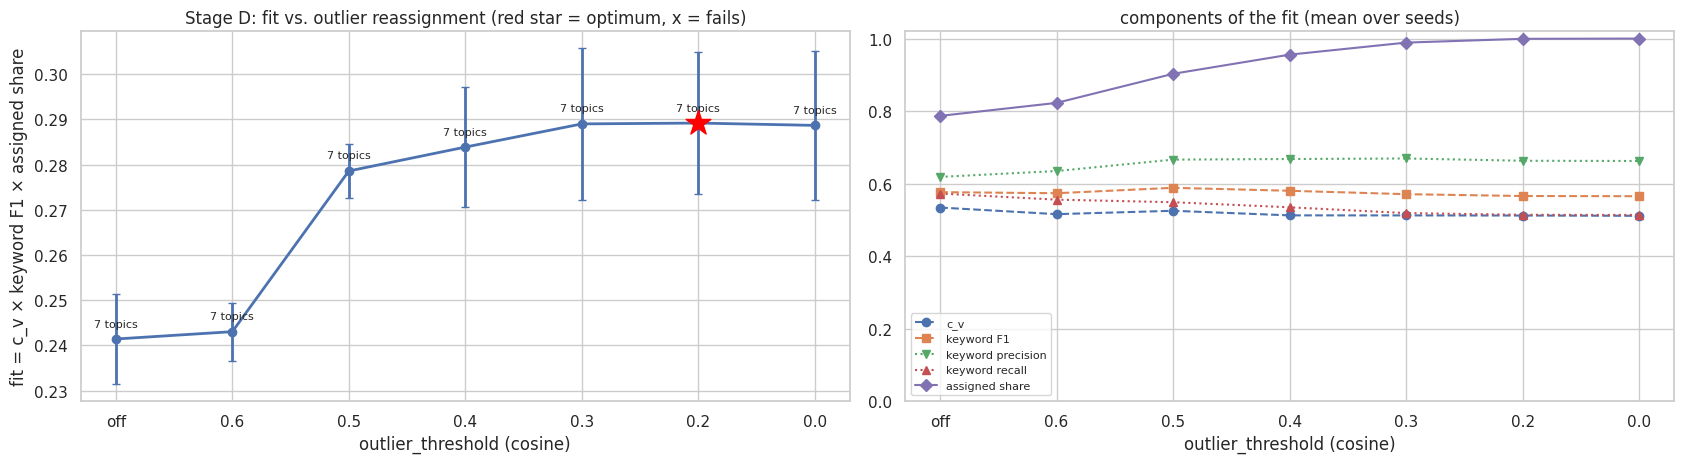

Best threshold: 0.2


In [23]:
cur = best_c["cfg"]
THRESHOLDS = [None, 0.6, 0.5, 0.4, 0.3, 0.2, 0.0]
for thr in THRESHOLDS:
    run_config({"outlier_threshold": thr}, stage="D Outlier reassignment", base=cur,
               tag=f" threshold={'off' if thr is None else thr}")

d_ = stage_df("D Outlier reassignment").reset_index(drop=True)
best_d = best_record(["D Outlier reassignment"])
xl = ["off" if _is_none(v) else f"{v:.1f}" for v in d_["outlier_threshold"]]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 4.8))
ax1.errorbar(range(len(d_)), d_["fit"], yerr=d_["fit_std"], fmt="o-", lw=2, capsize=3)
for i, r in d_.iterrows():
    ax1.annotate(f"{r['n_topics']:.0f} topics", (i, r["fit"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
    if not np.isfinite(r["score"]):
        ax1.scatter([i], [r["fit"]], marker="x", s=90, color="gray", zorder=5)
d_recs = [r for r in LOG if r["stage"] == "D Outlier reassignment"]
bi = [i for i, r in enumerate(d_recs) if r is best_d]
if bi:
    ax1.scatter(bi, [best_d["fit"]], marker="*", s=350, color="red", zorder=6, label="optimum")
ax1.set_xticks(range(len(d_))); ax1.set_xticklabels(xl); ax1.set_xlabel("outlier_threshold (cosine)")
ax1.set_ylabel(FIT_LABEL); ax1.set_title("Stage D: fit vs. outlier reassignment (red star = optimum, x = fails)")
plot_components(ax2, range(len(d_)), d_, "outlier_threshold (cosine)")
ax2.set_xticks(range(len(d_))); ax2.set_xticklabels(xl)
plt.tight_layout(); plt.show()
print("Best threshold:", "off" if _is_none(best_d["outlier_threshold"]) else best_d["outlier_threshold"])

### Stage E — topic-word extraction (c-TF-IDF variants & phrases)

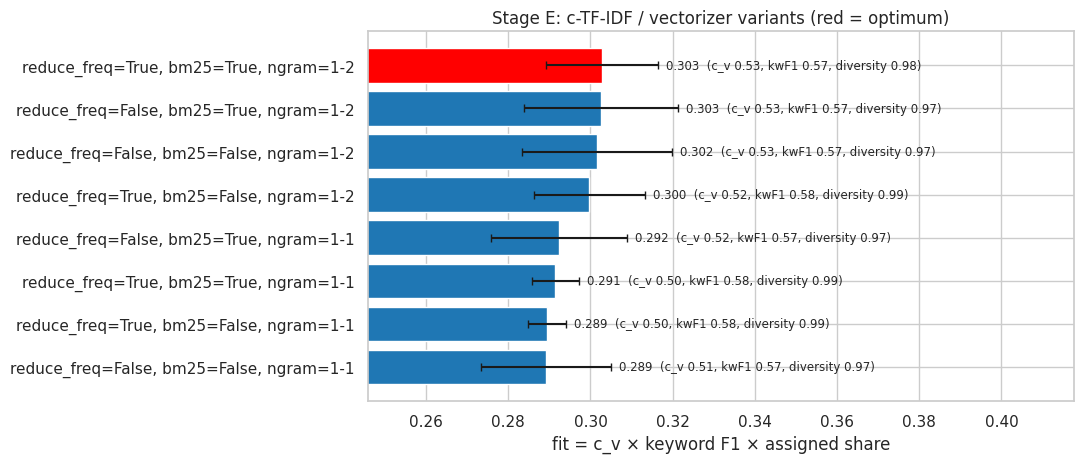

In [24]:
cur = best_d["cfg"]
for rfw in (False, True):
    for bm25 in (False, True):
        for ng in (1, 2):
            run_config({"reduce_frequent_words": rfw, "bm25": bm25, "ngram_max": ng},
                       stage="E c-TF-IDF variants", base=cur, verbose=False)

e = stage_df("E c-TF-IDF variants")
e["variant"] = e.apply(lambda r: f"reduce_freq={r.reduce_frequent_words}, bm25={r.bm25}, ngram=1-{r.ngram_max}", axis=1)
e = e.sort_values("fit").reset_index(drop=True)
best_e = best_record(["E c-TF-IDF variants"])
fig, ax = plt.subplots(figsize=(11, 4.8))
cols = ["red" if (r.reduce_frequent_words == best_e["reduce_frequent_words"] and r.bm25 == best_e["bm25"]
                  and r.ngram_max == best_e["ngram_max"]) else "tab:blue" for r in e.itertuples()]
ax.barh(e["variant"], e["fit"], xerr=e["fit_std"], color=cols, capsize=3)
for y_, r in e.iterrows():
    ax.text(r["fit"] + r["fit_std"] + 0.002, y_, f"{r['fit']:.3f}  (c_v {r['c_v']:.2f}, kwF1 {r['kw_f1']:.2f}, "
            f"diversity {r['diversity']:.2f})", va="center", fontsize=8.5)
ax.set_xlim(e["fit"].min() * 0.85, (e["fit"] + e["fit_std"]).max() * 1.3)
ax.set_xlabel(FIT_LABEL); ax.set_title("Stage E: c-TF-IDF / vectorizer variants (red = optimum)")
plt.tight_layout(); plt.show()

### Stage F — topic reduction (`nr_topics`)

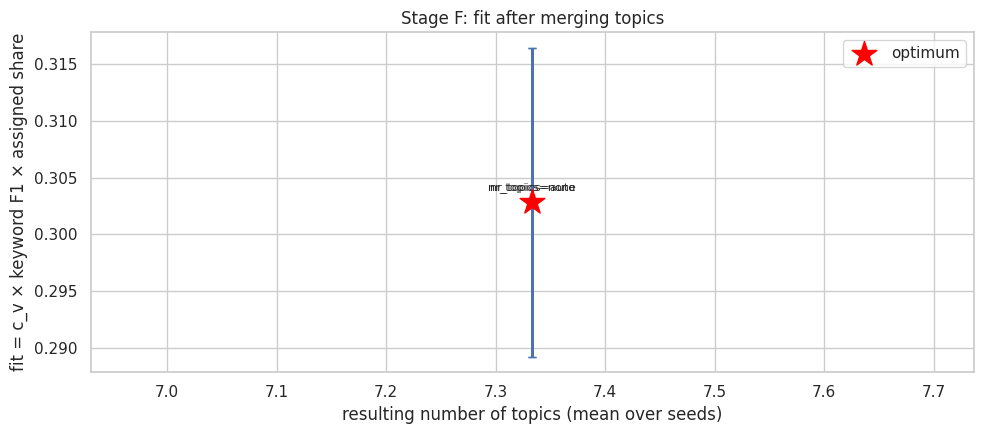

In [25]:
cur = best_e["cfg"]
n_base = int(round(best_e["n_topics"]))
targets = [None, "auto"]
if n_base - 1 > MIN_TOPICS:
    targets += sorted(set(np.linspace(MIN_TOPICS + 1, n_base, 6).astype(int).tolist()))
for k in targets:
    run_config({"nr_topics": k}, stage="F Topic reduction", base=cur, verbose=False)

f_ = stage_df("F Topic reduction")
best_f = best_record(["F Topic reduction"])
f_["setting"] = f_["nr_topics"].apply(lambda v: "none" if _is_none(v) else str(v))
f_s = f_.sort_values("n_topics")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.errorbar(f_s["n_topics"], f_s["fit"], yerr=f_s["fit_std"], fmt="o-", lw=2, capsize=3)
for r in f_s.itertuples():
    ax.annotate(f"nr_topics={r.setting}", (r.n_topics, r.fit), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
ax.scatter([best_f["n_topics"]], [best_f["fit"]], marker="*", s=350, color="red", zorder=5, label="optimum")
ax.set_xlabel("resulting number of topics (mean over seeds)"); ax.set_ylabel(FIT_LABEL)
ax.set_title("Stage F: fit after merging topics"); ax.legend()
plt.tight_layout(); plt.show()

### Stage G — joint search: Random search vs. Bayesian optimisation (Optuna TPE)
Both search all settings at once (embedding, UMAP, HDBSCAN incl. `min_samples` and `leaf` selection, outlier threshold, c-TF-IDF options, phrases, `nr_topics`) with the same budget of `N_TRIALS` configurations, each scored on all seeds. **The two samplers use different seeds.** In v4 they shared one, so TPE's 8 random start-up trials were identical to the first 8 random-search trials, and both "found" the same result.

In [26]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(stage):
    def objective(trial):
        mcs = trial.suggest_int("min_cluster_size", 5, 40)
        nr = trial.suggest_categorical("nr_topics", ["none", "auto"])
        cfg = dict(
            emb=trial.suggest_categorical("emb", ELIGIBLE_EMB),
            n_neighbors=trial.suggest_int("n_neighbors", 5, 60),
            n_components=trial.suggest_int("n_components", 2, 15),
            min_cluster_size=mcs,
            min_samples=trial.suggest_int("min_samples", 1, mcs),
            method=trial.suggest_categorical("method", ["eom", "leaf"]),
            ngram_max=trial.suggest_int("ngram_max", 1, 2),
            reduce_frequent_words=trial.suggest_categorical("reduce_frequent_words", [False, True]),
            bm25=trial.suggest_categorical("bm25", [False, True]),
            outlier_threshold=trial.suggest_float("outlier_threshold", 0.0, 0.6),
            nr_topics=None if nr == "none" else nr)
        _, rec = run_config(cfg, stage, verbose=False)
        if (trial.number + 1) % 10 == 0:
            print(f"  {stage}: trial {trial.number + 1}/{N_TRIALS}")
        return 0.0 if not np.isfinite(rec["score"]) else rec["score"]
    return objective

t0 = time.time()
study_rand = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=SEED))
study_rand.optimize(make_objective("G Random search"), n_trials=N_TRIALS)
study_tpe = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED + 1000, n_startup_trials=8, multivariate=True))
study_tpe.optimize(make_objective("G Bayesian (TPE)"), n_trials=N_TRIALS)
print(f"Joint search done in {time.time() - t0:.0f}s | best random={study_rand.best_value:.3f} | best TPE={study_tpe.best_value:.3f}")

  G Random search: trial 10/30
  G Random search: trial 20/30
  G Random search: trial 30/30
  G Bayesian (TPE): trial 10/30
  G Bayesian (TPE): trial 20/30
  G Bayesian (TPE): trial 30/30
Joint search done in 359s | best random=0.290 | best TPE=0.322


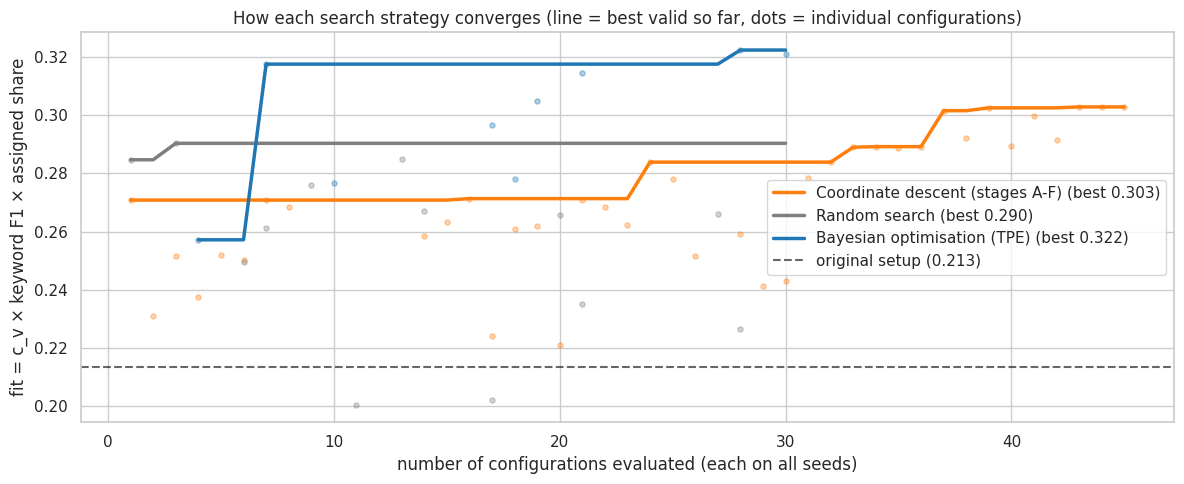

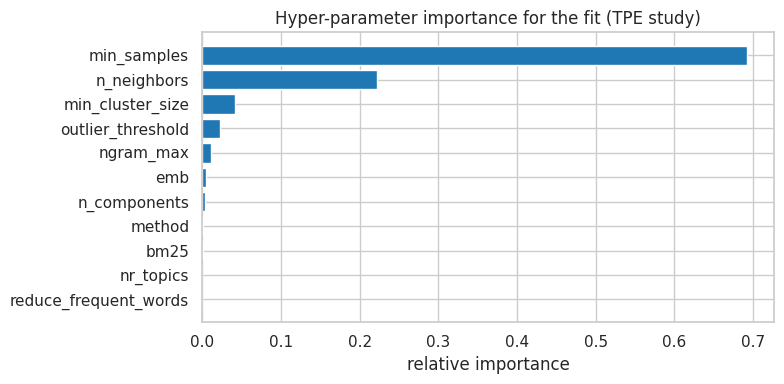

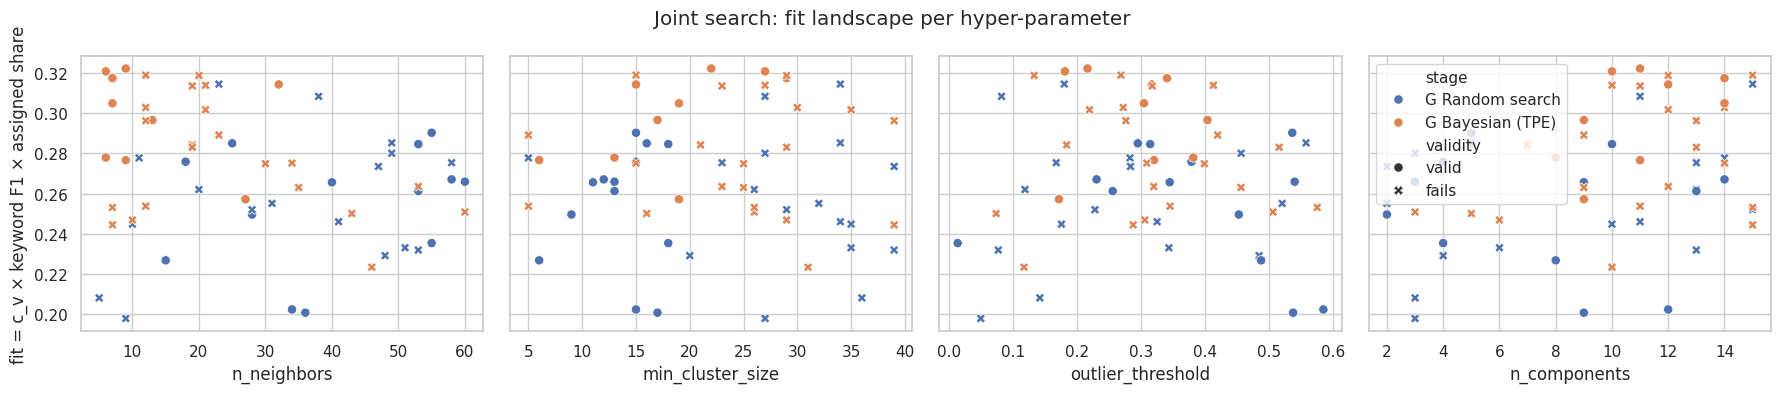

In [27]:
def best_so_far(vals):
    out, cur = [], -np.inf
    for v in vals:
        if np.isfinite(v):
            cur = max(cur, v)
        out.append(cur if np.isfinite(cur) else np.nan)
    return out

curves = {
    "Coordinate descent (stages A-F)": [r["score"] for r in LOG if r["stage"][0] in "ABCDEF" and r["eligible"]],
    "Random search":                   [r["score"] for r in LOG if r["stage"] == "G Random search"],
    "Bayesian optimisation (TPE)":     [r["score"] for r in LOG if r["stage"] == "G Bayesian (TPE)"],
}
fig, ax = plt.subplots(figsize=(12, 5))
for (name, vals), col in zip(curves.items(), ["tab:orange", "tab:gray", "tab:blue"]):
    if not vals:
        continue
    xv = np.arange(1, len(vals) + 1)
    ax.scatter(xv, vals, s=14, alpha=0.35, color=col)
    ax.plot(xv, best_so_far(vals), lw=2.5, color=col, label=f"{name} (best {np.nanmax(np.r_[vals, np.nan]) if np.isfinite(vals).any() else float('nan'):.3f})")
ax.axhline(baseline["fit"], ls="--", color="black", alpha=0.6, label=f"original setup ({baseline['fit']:.3f})")
ax.set_xlabel("number of configurations evaluated (each on all seeds)"); ax.set_ylabel(FIT_LABEL)
ax.set_title("How each search strategy converges (line = best valid so far, dots = individual configurations)")
ax.legend(); plt.tight_layout(); plt.show()

try:
    imp = optuna.importance.get_param_importances(study_tpe)
    plt.figure(figsize=(8, 4))
    plt.barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="tab:blue")
    plt.xlabel("relative importance"); plt.title("Hyper-parameter importance for the fit (TPE study)")
    plt.tight_layout(); plt.show()
except Exception as ex:
    print("Importance plot skipped:", ex)

g = pd.concat([stage_df("G Random search"), stage_df("G Bayesian (TPE)")]).reset_index(drop=True)
g["validity"] = g["score"].isna().map({True: "fails", False: "valid"})
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, p in zip(axes, ["n_neighbors", "min_cluster_size", "outlier_threshold", "n_components"]):
    sns.scatterplot(data=g, x=p, y="fit", hue="stage", style="validity", ax=ax, s=45)
    leg = ax.get_legend()
    if leg is not None and ax is not axes[-1]:
        leg.remove()
axes[0].set_ylabel(FIT_LABEL)
fig.suptitle("Joint search: fit landscape per hyper-parameter"); plt.tight_layout(); plt.show()

### Stage H — guided (zero-shot) topics
The themes found so far are written down in `ZEROSHOT_TOPICS` (Section 11.3; edit them freely). BERTopic assigns a sentence to one of these themes when its embedding is at least `zeroshot_min_similarity` similar to the theme's description, and clusters the rest as before. Same settings as the best unsupervised model, same score. If it wins, the final model uses it and its theme names become title candidates. If BERTopic's zero-shot feature is unavailable in the installed version, this stage is skipped.

  [H Zero-shot min_sim=0.35] fit=0.252±0.004  c_v=0.530  kwF1=0.48 (P 0.61/R 0.44)  assigned=100%  topics=11.7
  [H Zero-shot min_sim=0.45] fit=0.235±0.013  c_v=0.483  kwF1=0.49 (P 0.63/R 0.45)  assigned=100%  topics=12.7
  [H Zero-shot min_sim=0.55] fit=0.260±0.013  c_v=0.514  kwF1=0.51 (P 0.68/R 0.44)  assigned=100%  topics=9.7


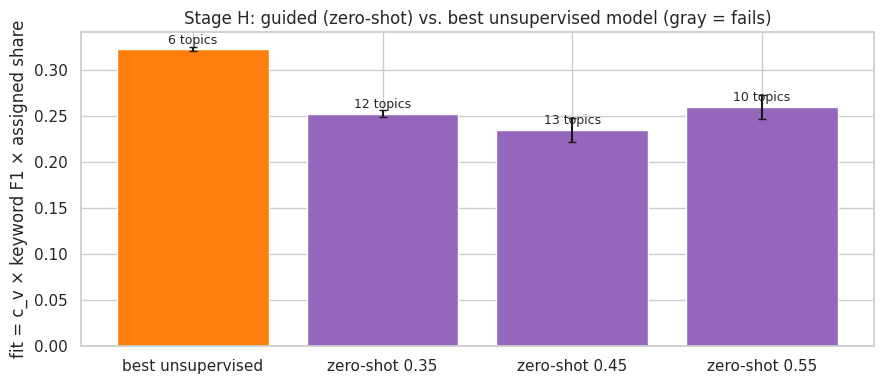

In [28]:
UNSUP_STAGES = ["A Embedding", "B HDBSCAN min_cluster_size", "C UMAP grid", "D Outlier reassignment",
                "E c-TF-IDF variants", "F Topic reduction", "G Random search", "G Bayesian (TPE)"]
best_unsup = best_record(UNSUP_STAGES)
if USE_ZEROSHOT:
    zs_base = {**best_unsup["cfg"], "nr_topics": None}
    for zs in [0.35, 0.45, 0.55]:
        run_config({"zs_min_sim": zs}, stage="H Zero-shot", base=zs_base, tag=f" min_sim={zs}")
    h = stage_df("H Zero-shot")
    if len(h) and np.isfinite(h["fit"]).any():
        labels = ["best unsupervised"] + [f"zero-shot {v:.2f}" for v in h["zs_min_sim"]]
        vals = [best_unsup["fit"]] + h["fit"].tolist()
        sds = [best_unsup["fit_std"]] + h["fit_std"].tolist()
        ok = [np.isfinite(best_unsup["score"])] + h["score"].notna().tolist()
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.bar(labels, np.nan_to_num(vals), yerr=np.nan_to_num(sds), capsize=3,
               color=["tab:orange"] + ["tab:purple" if o else "lightgray" for o in ok[1:]])
        for i, (v, n) in enumerate(zip(vals, [best_unsup["n_topics"]] + h["n_topics"].tolist())):
            ax.text(i, np.nan_to_num(v) + 0.006, f"{n:.0f} topics", ha="center", fontsize=9)
        ax.set_ylabel(FIT_LABEL); ax.set_title("Stage H: guided (zero-shot) vs. best unsupervised model (gray = fails)")
        plt.tight_layout(); plt.show()
    else:
        print("Zero-shot fits failed (see messages above) - continuing with the unsupervised model.")
else:
    print("USE_ZEROSHOT = False - stage skipped.")

### Stage I — stability of the overall winner on five new seeds
The winner was chosen using `SEARCH_SEEDS`; refitting on seeds it has never seen shows how much of its score is luck. The **adjusted Rand index (ARI)** between two runs measures how similarly they group the sentences (1 = identical grouping, 0 = no better than chance).

Overall best stage: G Bayesian (TPE)
Config: {'emb': 'mpnet|masked', 'n_neighbors': 9, 'n_components': 11, 'min_cluster_size': 22, 'min_samples': 15, 'method': 'eom', 'ngram_max': 1, 'reduce_frequent_words': True, 'bm25': False, 'nr_topics': None, 'outlier_threshold': 0.2169328338114912, 'zs_min_sim': None}
fit=0.322±0.002  c_v=0.593  c_npmi=0.063  kwF1=0.54 (P 0.70/R 0.47)  topics=6.0  assigned=100%


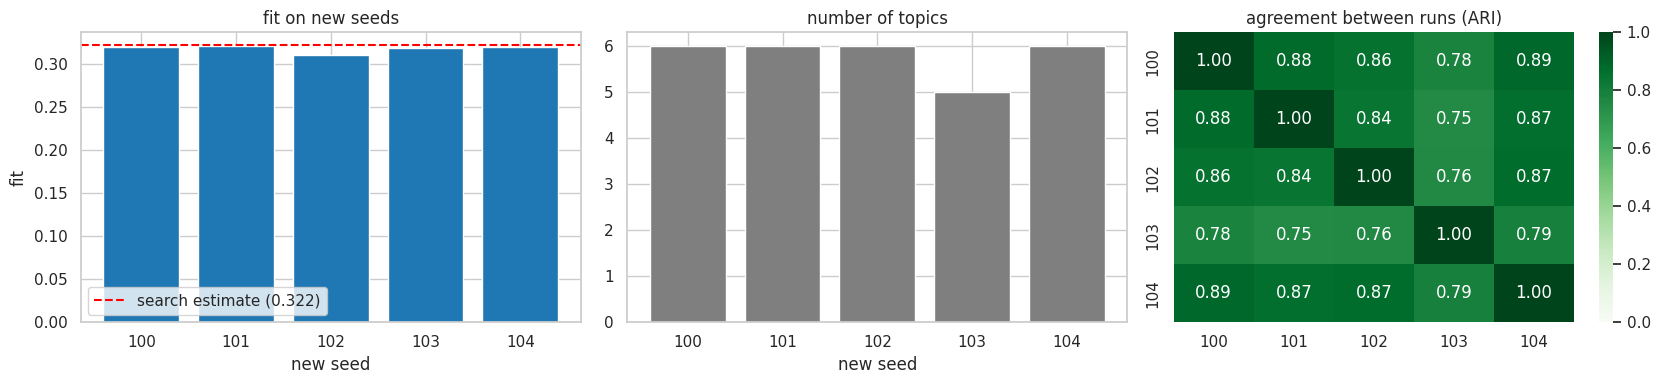

New seeds: fit 0.318 ± 0.004 | mean pairwise ARI 0.83


In [29]:
from sklearn.metrics import adjusted_rand_score

overall = best_record()
print("Overall best stage:", overall["stage"])
print("Config:", {k: overall["cfg"][k] for k in BASE_CFG})
print(f"fit={overall['fit']:.3f}±{overall['fit_std']:.3f}  c_v={overall['c_v']:.3f}  c_npmi={overall['c_npmi']:.3f}  "
      f"kwF1={overall['kw_f1']:.2f} (P {overall['precision']:.2f}/R {overall['recall']:.2f})  "
      f"topics={overall['n_topics']:.1f}  assigned={overall['assigned']:.0%}")

stab_seeds = [100, 101, 102] if FAST_MODE else [100, 101, 102, 103, 104]
_, stab = run_config({}, stage="I Stability", base=overall["cfg"], seeds=stab_seeds, verbose=False)
runs = [t for t in stab["topics_by_seed"] if t is not None]
ari = np.full((len(runs), len(runs)), np.nan)
for i in range(len(runs)):
    for j in range(len(runs)):
        ari[i, j] = adjusted_rand_score(runs[i], runs[j])
off_diag = ari[~np.eye(len(runs), dtype=bool)] if len(runs) > 1 else np.array([np.nan])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar([str(s) for s in stab_seeds], np.nan_to_num(stab["fits"]), color="tab:blue")
axes[0].axhline(overall["fit"], color="red", ls="--", label=f"search estimate ({overall['fit']:.3f})")
axes[0].set_xlabel("new seed"); axes[0].set_ylabel("fit"); axes[0].legend(); axes[0].set_title("fit on new seeds")
axes[1].bar([str(s) for s in stab_seeds], [len(set(t.tolist()) - {-1}) if t is not None else 0 for t in stab["topics_by_seed"]],
            color="tab:gray")
axes[1].set_xlabel("new seed"); axes[1].set_title("number of topics")
sns.heatmap(ari, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="Greens", ax=axes[2],
            xticklabels=stab_seeds[:len(runs)], yticklabels=stab_seeds[:len(runs)])
axes[2].set_title("agreement between runs (ARI)")
plt.tight_layout(); plt.show()
print(f"New seeds: fit {np.nanmean(stab['fits']):.3f} ± {np.nanstd(stab['fits']):.3f} | "
      f"mean pairwise ARI {np.nanmean(off_diag):.2f}")

### Optimisation summary

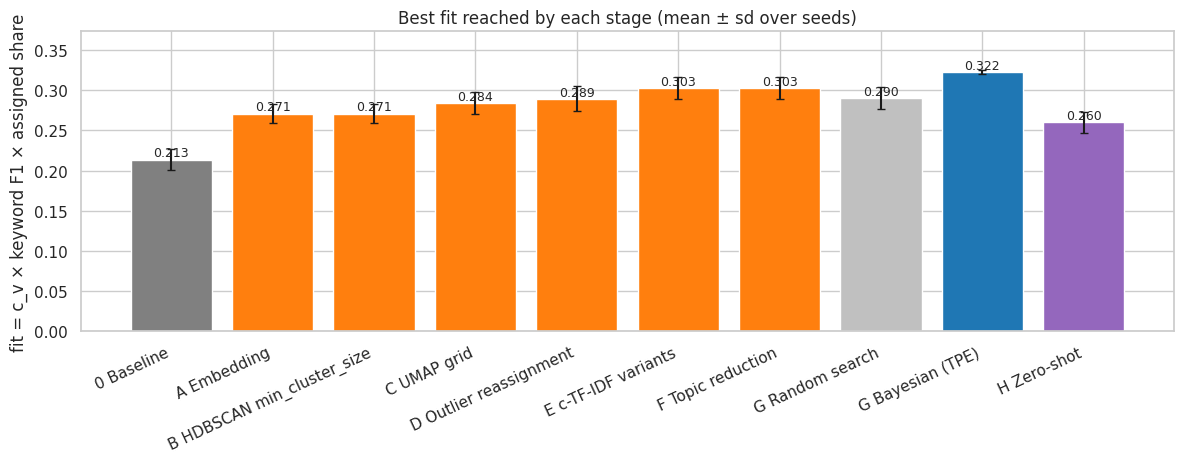

,stage,fit,sd,c_v,c_npmi,kw_F1,precision,recall,assigned,topics,diversity
0,0 Baseline,0.213,0.013,0.500,0.014,0.603,0.598,0.694,0.709,10.667,0.984
1,A Embedding,0.271,0.012,0.525,0.050,0.549,0.620,0.530,0.940,7.667,0.981
2,B HDBSCAN min_cluster_size,0.271,0.012,0.525,0.050,0.549,0.620,0.530,0.940,7.667,0.981
3,C UMAP grid,0.284,0.013,0.512,0.045,0.580,0.668,0.534,0.956,7.333,0.973
4,D Outlier reassignment,0.289,0.016,0.512,0.045,0.566,0.663,0.514,0.999,7.333,0.973
5,E c-TF-IDF variants,0.303,0.014,0.528,0.046,0.574,0.695,0.508,0.999,7.333,0.978
6,F Topic reduction,0.303,0.014,0.528,0.046,0.574,0.695,0.508,0.999,7.333,0.978
7,G Random search,0.290,0.014,0.539,0.029,0.542,0.723,0.483,0.998,6.667,1.000
8,G Bayesian (TPE),0.322,0.002,0.593,0.063,0.544,0.705,0.473,0.998,6.000,0.983
9,H Zero-shot,0.260,0.013,0.514,0.000,0.506,0.681,0.440,0.999,9.667,0.975


,stage,emb,n_neighbors,n_components,min_cluster_size,min_samples,method,outlier_threshold,ngram_max,reduce_frequent_words,bm25,nr_topics,zs_min_sim,fit,fit_std,c_v,kw_f1,precision,recall,assigned,n_topics
107,G Bayesian (TPE),mpnet|masked,9,11,22,15.0,eom,0.217,1,True,False,None,NaN,0.322,0.002,0.593,0.544,0.705,0.473,0.998,6.000
109,G Bayesian (TPE),mpnet|masked,6,10,27,17.0,eom,0.182,1,True,False,None,NaN,0.321,0.005,0.600,0.535,0.716,0.457,1.000,5.667
86,G Bayesian (TPE),mpnet|masked,7,14,29,12.0,eom,0.341,1,True,False,None,NaN,0.318,0.009,0.579,0.560,0.700,0.490,0.979,5.667
100,G Bayesian (TPE),mpnet|masked,32,12,15,11.0,eom,0.317,1,True,False,None,NaN,0.314,0.005,0.545,0.589,0.747,0.497,0.980,5.333
98,G Bayesian (TPE),mpnet|masked,7,14,19,11.0,eom,0.305,1,True,False,None,NaN,0.305,0.012,0.539,0.573,0.689,0.515,0.987,8.000
49,F Topic reduction,mpnet|masked,30,5,10,NaN,eom,0.200,2,True,True,auto,NaN,0.303,0.014,0.528,0.574,0.695,0.508,0.999,7.333
48,F Topic reduction,mpnet|masked,30,5,10,NaN,eom,0.200,2,True,True,None,NaN,0.303,0.014,0.528,0.574,0.695,0.508,0.999,7.333
47,E c-TF-IDF variants,mpnet|masked,30,5,10,NaN,eom,0.200,2,True,True,None,NaN,0.303,0.014,0.528,0.574,0.695,0.508,0.999,7.333
43,E c-TF-IDF variants,mpnet|masked,30,5,10,NaN,eom,0.200,2,False,True,None,NaN,0.303,0.019,0.534,0.567,0.661,0.518,0.999,7.333
41,E c-TF-IDF variants,mpnet|masked,30,5,10,NaN,eom,0.200,2,False,False,None,NaN,0.302,0.018,0.534,0.565,0.662,0.514,0.999,7.333


In [30]:
stages = ["0 Baseline", "A Embedding", "B HDBSCAN min_cluster_size", "C UMAP grid", "D Outlier reassignment",
          "E c-TF-IDF variants", "F Topic reduction", "G Random search", "G Bayesian (TPE)", "H Zero-shot"]
summ = []
for s in stages:
    try:
        r = best_record([s], eligible_only=(s != "0 Baseline"))
    except RuntimeError:
        continue
    summ.append({"stage": s, "fit": r["fit"], "sd": r["fit_std"], "c_v": r["c_v"], "c_npmi": r["c_npmi"],
                 "kw_F1": r["kw_f1"], "precision": r["precision"], "recall": r["recall"],
                 "assigned": r["assigned"], "topics": r["n_topics"], "diversity": r["diversity"]})
summ = pd.DataFrame(summ)
fig, ax = plt.subplots(figsize=(12, 4.8))
stage_color = lambda s: "gray" if s.startswith("0") else ("tab:blue" if "TPE" in s else ("silver" if "Random" in s
                        else ("tab:purple" if s.startswith("H") else "tab:orange")))
bars = ax.bar(summ["stage"], summ["fit"], yerr=summ["sd"], capsize=3, color=[stage_color(s) for s in summ["stage"]])
for b_, v in zip(bars, summ["fit"]):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, (summ["fit"] + summ["sd"].fillna(0)).max() * 1.15)
ax.set_ylabel(FIT_LABEL); ax.set_title("Best fit reached by each stage (mean ± sd over seeds)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
show_table(summ.round(3))

log_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cfg", "topics_by_seed")} for r in LOG])
log_df.to_csv("/content/bertopic_optimisation_log.csv", index=False)
cols = ["stage", "emb", "n_neighbors", "n_components", "min_cluster_size", "min_samples", "method", "outlier_threshold",
        "ngram_max", "reduce_frequent_words", "bm25", "nr_topics", "zs_min_sim", "fit", "fit_std", "c_v", "kw_f1",
        "precision", "recall", "assigned", "n_topics"]
show_table(log_df[(log_df["stage"] != "I Stability") & log_df["eligible"]]
           .sort_values("score", ascending=False).head(10)[cols].round(3))

## 13. Final Model & Readable Topics (no LLM API)
1. Refit the overall winner with the **median seed** of its search runs (not the luckiest seed), including outlier reassignment, and add two extra keyword representations (**KeyBERTInspired**, **MaximalMarginalRelevance**). The representation with the best fit is used for display.
2. Map the topics back to **every** sentence (repeats inherit their representative's topic) and score every sentence with Twitter-RoBERTa.
3. Pick **diverse** example sentences per topic (MMR): relevant to the topic's keywords and centre, but not near-copies of each other. In v4 the examples were all the same repeated line, so the "summary" was that line.
4. A small instruct model writes a neutral one-sentence summary of the *group* (rejected and retried if it just copies one example). Several **title candidates** (the LLM's title, a keyword title, and, when relevant, a guided theme name) are ranked by semantic similarity to the topic's sentences; all candidates and scores are printed so you can overrule the choice.

Final configuration from stage 'G Bayesian (TPE)', refit with median seed 7 (search fits per seed: [0.32, 0.323, 0.325])
Final model: 6 topics | fit=0.323 | c_v=0.594 | c_npmi=0.066 | keyword F1=0.54 (P 0.71 / R 0.47) | unassigned=0%


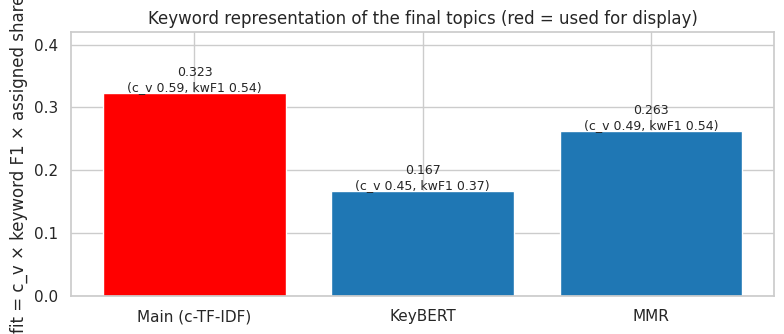

In [31]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

overall = best_record()
FINAL_CFG = dict(overall["cfg"])
_fits = np.asarray(overall["fits"], dtype=float)
_order = [i for i in np.argsort(_fits) if np.isfinite(_fits[i])]
FINAL_SEED = overall["seeds"][_order[(len(_order) - 1) // 2]] if _order else SEED
EMB_SHORT = FINAL_CFG["emb"].split("|")[0]
print(f"Final configuration from stage '{overall['stage']}', refit with median seed {FINAL_SEED} "
      f"(search fits per seed: {np.round(_fits, 3).tolist()})")

REP_MODELS = {"KeyBERT": KeyBERTInspired(), "MMR": MaximalMarginalRelevance(diversity=0.3)}
final_model = fit_once(FINAL_CFG, FINAL_SEED, representation_model=REP_MODELS, embedding_model=ST[EMB_SHORT])
TOPICS_U = np.asarray(final_model.topics_)
final_metrics = evaluate(final_model)
print(f"Final model: {final_metrics['n_topics']} topics | fit={final_metrics['fit']:.3f} | c_v={final_metrics['c_v']:.3f} "
      f"| c_npmi={final_metrics['c_npmi']:.3f} | keyword F1={final_metrics['kw_f1']:.2f} "
      f"(P {final_metrics['precision']:.2f} / R {final_metrics['recall']:.2f}) | unassigned={final_metrics['outlier_pct']:.0%}")

rep_rows, REP_METRICS = [], {}
for asp in ["Main (c-TF-IDF)", "KeyBERT", "MMR"]:
    try:
        m = evaluate(final_model, None if asp.startswith("Main") else asp)
    except Exception as ex:
        print(f"{asp} representation skipped: {ex}")
        continue
    if m["n_topics"] == 0 or not np.isfinite(m["fit"]):
        continue
    REP_METRICS[asp] = m
    rep_rows.append({"representation": asp, "fit": m["fit"], "c_v": m["c_v"], "kw_f1": m["kw_f1"], "diversity": m["diversity"]})
rep_df = pd.DataFrame(rep_rows)
BEST_ASPECT = rep_df.loc[rep_df["fit"].idxmax(), "representation"] if len(rep_df) else "Main (c-TF-IDF)"

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(rep_df["representation"], rep_df["fit"], color=["red" if r == BEST_ASPECT else "tab:blue" for r in rep_df["representation"]])
for i, r in rep_df.reset_index(drop=True).iterrows():
    ax.text(i, r["fit"] + 0.003, f"{r['fit']:.3f}\n(c_v {r['c_v']:.2f}, kwF1 {r['kw_f1']:.2f})", ha="center", fontsize=9)
ax.set_ylim(0, rep_df["fit"].max() * 1.3 if len(rep_df) else 1)
ax.set_ylabel(FIT_LABEL); ax.set_title("Keyword representation of the final topics (red = used for display)")
plt.tight_layout(); plt.show()

In [32]:
TOPICS_ALL = to_all(TOPICS_U)
info = pd.DataFrame({"Sentence": DOCS_ORIG, "Masked": DOCS_EMB, "Date": DOCS_DATES, "Topic": TOPICS_ALL,
                     "Unique": [int(REP[i]) == i for i in range(len(DOCS))]})
info["Sentiment"], _ = roberta_sentiment(DOCS_ORIG)

KW = topic_terms(final_model, None if BEST_ASPECT.startswith("Main") else BEST_ASPECT, topn=10)
PER_TOPIC = REP_METRICS.get(BEST_ASPECT, final_metrics)["per_topic"]
TOPIC_IDS = sorted(t for t in set(TOPICS_U.tolist()) if t != -1)
E_U = EMB[FINAL_CFG["emb"]][UNIQ]
E_LAB = EMB[f"{EMB_SHORT}|masked"][UNIQ]          # sentence embeddings used to judge titles
CENT = {}
for t in TOPIC_IDS:
    v = E_LAB[TOPICS_U == t].mean(axis=0)
    CENT[t] = v / (np.linalg.norm(v) + 1e-12)

def kw_score_u(j, words, topn=10):
    """How strongly unique sentence j matches a topic's keywords (higher-ranked keywords count more)."""
    return sum((topn - r) / topn for r, w in enumerate(words[:topn]) if w in DOC_TERMS_U[j])

def _unit(v):
    v = np.asarray(v, dtype=float)
    return (v - v.min()) / (v.max() - v.min()) if v.max() > v.min() else np.ones_like(v)

def examples_for(t, k=6, lam=0.7):
    """Maximal marginal relevance: relevant (keywords + centrality) but not near-copies of each other."""
    idx = np.where(TOPICS_U == t)[0]
    if len(idx) == 0:
        return []
    words = KW.get(t, [])
    kws = np.array([kw_score_u(j, words) for j in idx])
    ok_len = np.array([6 <= len(DOCS_ORIG_U[j].split()) <= 60 for j in idx])
    mask = ok_len & (kws > 0)
    if mask.sum() < min(k, len(idx)):
        mask = ok_len if ok_len.sum() >= min(k, len(idx)) else np.ones(len(idx), dtype=bool)
    cand = idx[mask]
    rel = 0.5 * _unit(kws[mask]) + 0.5 * _unit(E_LAB[cand] @ CENT[t])
    chosen = []
    for _ in range(min(k, len(cand))):
        red = (E_LAB[cand] @ E_LAB[chosen].T).max(axis=1) if chosen else np.zeros(len(cand))
        score = lam * rel - (1 - lam) * red
        score[np.isin(cand, chosen)] = -np.inf
        chosen.append(int(cand[int(np.argmax(score))]))
    return [DOCS_ORIG_U[j] for j in chosen]

print(f"{len(TOPIC_IDS)} topics | {len(info)} sentences ({int(info['Unique'].sum())} unique) | "
      f"unassigned: {(TOPICS_U == -1).mean():.0%} of unique sentences")

6 topics | 548 sentences (511 unique) | unassigned: 0% of unique sentences


In [33]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM

def _from_pretrained(cls, name, dtype):
    try:
        return cls.from_pretrained(name, dtype=dtype)
    except TypeError:                                   # older transformers use torch_dtype
        return cls.from_pretrained(name, torch_dtype=dtype)

def load_labeler(backend):
    if backend == "qwen":
        try:
            with quiet():
                tok = AutoTokenizer.from_pretrained(QWEN_MODEL)
                mdl = _from_pretrained(AutoModelForCausalLM, QWEN_MODEL, torch.float16 if HAS_GPU else torch.float32)
            mdl = mdl.to(TORCH_DEVICE).eval()
            def gen(prompt, max_new=60):
                msgs = [{"role": "system", "content": "You are a careful, neutral research assistant who summarises political speeches."},
                        {"role": "user", "content": prompt}]
                text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
                enc = tok(text, return_tensors="pt").to(TORCH_DEVICE)
                with torch.no_grad():
                    out = mdl.generate(**enc, max_new_tokens=max_new, do_sample=False, repetition_penalty=1.05,
                                       pad_token_id=tok.eos_token_id)
                return tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()
            gen("Reply with the word OK.", max_new=3)       # smoke test
            return gen, QWEN_MODEL
        except Exception as ex:
            print(f"Could not use {QWEN_MODEL} ({ex}); falling back to {LABEL_MODEL}.")
    with quiet():
        tok = AutoTokenizer.from_pretrained(LABEL_MODEL)
        mdl = AutoModelForSeq2SeqLM.from_pretrained(LABEL_MODEL).to(TORCH_DEVICE).eval()
    def gen(prompt, max_new=60):
        enc = tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(TORCH_DEVICE)
        with torch.no_grad():
            out = mdl.generate(**enc, max_new_tokens=max_new, num_beams=4, no_repeat_ngram_size=3, early_stopping=True)
        return tok.decode(out[0], skip_special_tokens=True).strip()
    return gen, LABEL_MODEL

GEN, GEN_NAME = load_labeler(LABEL_BACKEND)
print("Labels and summaries written by:", GEN_NAME)

Labels and summaries written by: Qwen/Qwen2.5-1.5B-Instruct


In [34]:
def cut(s, n=40):
    return " ".join(s.split()[:n])

def _words(text):
    return re.findall(r"[a-z]+", text.lower())

def _stem_match(a, b):
    n = len(os.path.commonprefix([a, b]))
    return n >= max(3, min(len(a), len(b)) - 2)

def mentions_keyword(text, keywords, n=8):
    toks = _words(text)
    kw = [w for k in keywords[:n] for w in k.split()]
    return any(_stem_match(tk, k) for k in kw for tk in toks)

def is_copy(text, examples, thr=0.6):
    """True if the text is (almost) one of the example sentences."""
    a = set(_words(text)) - ENGLISH_STOP_WORDS - {"trump", "says", "biden", "joe"}
    for e in examples:
        b = set(_words(e)) - ENGLISH_STOP_WORDS - {"trump", "says", "biden", "joe"}
        if a and b and len(a & b) / len(a | b) >= thr:
            return True
    return False

KEEP_CAPS = {"I", "Biden", "Joe", "America", "American", "Americans", "China", "Chinese", "Obama", "Hunter",
             "Democrats", "Democrat", "Republicans", "Kamala", "Harris", "Congress", "Mexico", "Ukraine"}

def tidy_summary(s):
    s = s.strip().strip('"').split("\n")[0].strip()
    s = re.sub(r"^(description|summary)\s*:\s*", "", s, flags=re.I).strip()
    if not s.lower().startswith("trump"):
        first = re.sub(r"\W.*", "", s.split()[0]) if s.split() else ""
        if first not in KEEP_CAPS and not first.isupper():
            s = s[:1].lower() + s[1:]
        s = "Trump says " + s
    return s if s.endswith((".", "!", "?")) else s + "."

def summarize_topic(examples, keywords):
    ex = "\n".join(f"- {cut(s)}" for s in examples)
    base = ("The sentences below come from ONE topic in Donald Trump's rally speeches about Joe Biden.\n"
            f"Key terms of the topic: {', '.join(keywords[:8])}.\n\nSentences:\n{ex}\n\n"
            "Write ONE neutral sentence (at most 30 words) that describes what Trump says about Biden across "
            "these sentences as a group. Use your own words and do not copy any sentence. Start with 'Trump says'.")
    for attempt in range(2):
        prompt = base if attempt == 0 else base + " Describe the common theme, not a single example."
        s = tidy_summary(GEN(prompt, max_new=70))
        if 5 <= len(s.split()) <= 45 and mentions_keyword(s, keywords) and not is_copy(s, examples):
            return s, GEN_NAME
    return ("Trump says: " + cut(examples[0], 30) + " (example sentence)") if examples else "(no example)", "extractive"

TITLE_BAD_END = {"of", "the", "and", "to", "a", "an", "in", "for", "with", "on", "at", "by", "or", "&"}

def tidy_title(s):
    s = s.strip().split("\n")[0]
    s = re.sub(r"^(title|topic|heading)\s*[:\-]\s*", "", s, flags=re.I).strip().strip('.:"\'*# ')
    s = re.sub(r"\b(Donald\s+)?Trump('s)?\b\s*", "", s).strip()
    s = re.sub(r"^(Joe\s+)?Biden('s)?\s+", "", s).strip()
    return s[:1].upper() + s[1:] if s else s

def title_ok(s, max_words=7):
    w = s.split()
    return 1 <= len(w) <= max_words and w[-1].lower().strip(",.") not in TITLE_BAD_END and any(len(x) > 2 for x in w)

def keyword_title(words, n=3):
    picked = words[:n]
    if not picked:
        return None
    s = picked[0] if len(picked) == 1 else ", ".join(picked[:-1]) + " & " + picked[-1]
    return s[:1].upper() + s[1:]

ZS_NAMES = list(ZEROSHOT_TOPICS)
ZS_VECS = ST[EMB_SHORT].encode(list(ZEROSHOT_TOPICS.values()), normalize_embeddings=True, show_progress_bar=False) \
    if USE_ZEROSHOT else None
ZS_LABEL_MIN_SIM = 0.45

def title_candidates(t, summary, keywords):
    prompt = (f"Key terms of a topic: {', '.join(keywords[:8])}.\nWhat the topic is about: {summary}\n\n"
              "Write a short, specific heading (2 to 5 words) for this topic, like a newspaper section heading. "
              "Do not use the names Trump or Biden. Reply with the heading only.")
    cands = {}
    llm = tidy_title(GEN(prompt, max_new=14))
    if title_ok(llm):
        cands[llm] = GEN_NAME
    kt = keyword_title(keywords)
    if kt:
        cands.setdefault(kt, "keywords")
    if ZS_VECS is not None:
        sims = np.asarray(ZS_VECS) @ CENT[t]
        j = int(np.argmax(sims))
        if sims[j] >= ZS_LABEL_MIN_SIM:
            cands.setdefault(ZS_NAMES[j], "guided theme")
    return cands

def pick_title(t, summary, keywords):
    cands = title_candidates(t, summary, keywords)
    if not cands:
        return f"Topic {t}", "fallback", {}
    names = list(cands)
    sims = np.asarray(ST[EMB_SHORT].encode(names, normalize_embeddings=True, show_progress_bar=False)) @ CENT[t]
    best = names[int(np.argmax(sims))]
    return best, cands[best], {n: round(float(s), 3) for n, s in zip(names, sims)}

LABELS, SUMMARIES, EXAMPLES, SOURCES, used = {}, {}, {}, {}, set()
for t in TOPIC_IDS:
    kw = KW.get(t, [])
    EXAMPLES[t] = examples_for(t, k=6)
    SUMMARIES[t], sum_src = summarize_topic(EXAMPLES[t], kw)
    lab, src, scores = pick_title(t, SUMMARIES[t], kw)
    if lab.lower() in used:
        lab = f"{lab} ({kw[0]})" if kw else f"{lab} ({t})"
    used.add(lab.lower())
    LABELS[t], SOURCES[t] = lab, (src, sum_src)
    pt = PER_TOPIC.get(t, {})
    print(f"Topic {t}: {lab}   [title from {src}; summary from {sum_src}]")
    print(f"   size {int((TOPICS_U == t).sum())} unique / {int((TOPICS_ALL == t).sum())} mentions | c_v {pt.get('c_v', np.nan):.2f} | "
          f"keyword P {pt.get('precision', np.nan):.0%} / R {pt.get('recall', np.nan):.0%}")
    print(textwrap.fill(SUMMARIES[t], 105, initial_indent="   ", subsequent_indent="   "))
    print(f"   keywords: {', '.join(kw[:8])}")
    print(f"   title candidates (similarity to the topic's sentences): {scores}\n")

final_model.set_topic_labels({**{t: f"{t}. {LABELS[t]}" for t in TOPIC_IDS},
                              **({-1: "Unassigned"} if (TOPICS_U == -1).any() else {})})

Topic 0: Plan, ban & destroy   [title from keywords; summary from Qwen/Qwen2.5-1.5B-Instruct]
   size 140 unique / 156 mentions | c_v 0.54 | keyword P 89% / R 39%
   Trump says that Joe Biden's plan includes imposing a $4 trillion tax hike, banning American energy,
   destroying the economy, shutting down schools, and providing free healthcare to illegal immigrants,
   among other measures.
   keywords: plan, ban, destroy, tax, pledge, economy, school, shut
   title candidates (similarity to the topic's sentences): {'Economic and Policy Blueprint': 0.358, 'Plan, ban & destroy': 0.376, 'Taxes, energy & the economy': 0.343}

Topic 1: 47-year political record   [title from guided theme; summary from Qwen/Qwen2.5-1.5B-Instruct]
   size 112 unique / 124 mentions | c_v 0.59 | keyword P 65% / R 48%
   Trump says that Joe Biden has spent the last 47 years offshoring American jobs, trading with China,
   and weakening trade agreements, leading to significant economic damage and job losses in th

In [35]:
rows = []
for t in TOPIC_IDS:
    sub = info[info["Topic"] == t]
    shares = sub["Sentiment"].value_counts(normalize=True)
    pt = PER_TOPIC.get(t, {})
    rows.append({"Topic": t, "Label": LABELS[t], "Unique": int((TOPICS_U == t).sum()), "Mentions": len(sub),
                 "c_v": pt.get("c_v", np.nan), "c_npmi": pt.get("c_npmi", np.nan),
                 "Precision": pt.get("precision", np.nan), "Recall": pt.get("recall", np.nan), "F1": pt.get("f1", np.nan),
                 "Negative": shares.get("negative", 0.0), "Neutral": shares.get("neutral", 0.0),
                 "Positive": shares.get("positive", 0.0), "Keywords": ", ".join(KW.get(t, [])[:8]),
                 "Summary": SUMMARIES[t], "Example": EXAMPLES[t][0] if EXAMPLES[t] else ""})
topic_summary = pd.DataFrame(rows).sort_values("Mentions", ascending=False).reset_index(drop=True)
topic_summary.to_csv("/content/topic_summary.csv", index=False)
info.to_csv("/content/biden_sentences_with_topics.csv", index=False)
show_table(topic_summary.drop(columns=["Example", "Summary"]).round(3))

n_un_u, n_un_all = int((TOPICS_U == -1).sum()), int((TOPICS_ALL == -1).sum())
print(f"\nUnassigned: {n_un_u} of {len(TOPICS_U)} unique sentences ({n_un_u / len(TOPICS_U):.0%}), "
      f"{n_un_all} of {len(TOPICS_ALL)} mentions")
print("\nPer topic: keyword precision (are the words specific to this topic?) / recall (do its sentences contain them?)")
for r in topic_summary.itertuples():
    flag = "   <-- weak topic, read its sentences before trusting the label" if r.F1 < 0.4 else ""
    print(f"  {r.Topic:>2}. {r.Label[:45]:<45} P {r.Precision:>4.0%}  R {r.Recall:>4.0%}{flag}")
    rng = np.random.default_rng(SEED)
    pool = [DOCS_ORIG_U[j] for j in np.where(TOPICS_U == r.Topic)[0]]
    for s in rng.choice(pool, size=min(3, len(pool)), replace=False):
        print("        -", textwrap.shorten(s, 120))

,Topic,Label,Unique,Mentions,c_v,c_npmi,Precision,Recall,F1,Negative,Neutral,Positive,Keywords
0,0,"Plan, ban & destroy",140,156,0.540,0.061,0.885,0.386,0.537,0.808,0.186,0.006,"plan, ban, destroy, tax, pledge, economy, school, shut"
1,1,47-year political record,112,124,0.594,0.050,0.651,0.482,0.554,0.815,0.137,0.048,"year, job, spend, trade, reverse, damage, china, nafta"
2,2,Bernie's Credentials: Criticizes Biden's Southern Border,116,117,0.382,0.008,0.625,0.345,0.444,0.427,0.513,0.060,"run, debate, vote, bernie, crowd, watch, time, ask"
3,3,Crime Debate: Biden's Soft on Crime Claims,58,61,0.804,0.132,0.886,0.534,0.667,0.721,0.230,0.049,"police, law, enforcement, bail, murder, officer, criminal, peaceful"
4,4,Hunter Biden & Ukraine,44,49,0.554,-0.012,0.551,0.864,0.673,0.510,0.490,0.000,"son, ukraine, china, hunter, money, pay, win, stage"
5,5,Leftist Critique of Biden's Platform,40,40,0.689,0.156,0.453,0.600,0.516,0.800,0.175,0.025,"left, kamala, platform, radical, party, wing, control, extreme"



Unassigned: 1 of 511 unique sentences (0%), 1 of 548 mentions

Per topic: keyword precision (are the words specific to this topic?) / recall (do its sentences contain them?)
   0. Plan, ban & destroy                           P  89%  R  39%
        - If Biden wins, the rioters and anarchists and -- Look, you see what's going on.
        - I said, Joe, it's $100 trillion, that's more money than this country can make in the next hundred years if [...]
        - And I'm asking Joe Biden to do the same thing, but he can't because he's got a bunch of radical-left maniacs that [...]
   1. 47-year political record                      P  65%  R  48%
        - Biden supported China's entry into the World Trade Organization which, by the way, was a disaster.
        - We've spent the last four years reversing the damage Joe Biden inflicted over his 47 years in politics along with [...]
        - He has passed criminal justice reform, prison reform, delivered permanent funding for historically 

### 13.1 Topic summaries in plain sentences
Each topic with its title, the neutral summary written above and the keywords. "Mentions" counts repeats of the same line; "unique" counts distinct lines.

In [36]:
import html as html_lib
from IPython.display import HTML

cards = []
for r in topic_summary.itertuples():
    cards.append(f"""
    <div style="border:1px solid #ccc;border-left:6px solid #c0392b;border-radius:6px;padding:10px 14px;margin:8px 0;">
      <div style="font-size:15px;font-weight:bold;">Topic {r.Topic}: {html_lib.escape(r.Label)}</div>
      <div style="font-size:12px;color:#666;margin:2px 0 6px;">{r.Mentions} mentions ({r.Unique} unique lines) &nbsp;|&nbsp;
        {r.Negative:.0%} negative, {r.Neutral:.0%} neutral, {r.Positive:.0%} positive &nbsp;|&nbsp;
        c_v {r.c_v:.2f} &nbsp;|&nbsp; keyword precision {r.Precision:.0%}, recall {r.Recall:.0%}</div>
      <div style="font-size:14px;line-height:1.45;">{html_lib.escape(r.Summary)}</div>
      <div style="font-size:12px;color:#777;margin-top:6px;">Keywords: {html_lib.escape(r.Keywords)}</div>
    </div>""")
cards.append(f"""<div style="font-size:12px;color:#666;margin:8px 0;">Unassigned: {n_un_all} of {len(TOPICS_ALL)} mentions
             ({n_un_u} of {len(TOPICS_U)} unique lines).</div>""")
text_cards = "\n\n".join(
    f"Topic {r.Topic}: {r.Label}\n   {r.Mentions} mentions ({r.Unique} unique lines) | {r.Negative:.0%} negative, "
    f"{r.Neutral:.0%} neutral, {r.Positive:.0%} positive | c_v {r.c_v:.2f} | keyword precision {r.Precision:.0%}, "
    f"recall {r.Recall:.0%}\n" + textwrap.fill(r.Summary, 110, initial_indent="   ", subsequent_indent="   ")
    + f"\n   Keywords: {r.Keywords}" for r in topic_summary.itertuples())
text_cards += f"\n\nUnassigned: {n_un_all} of {len(TOPICS_ALL)} mentions ({n_un_u} of {len(TOPICS_U)} unique lines)."
display({"text/html": "".join(cards), "text/plain": text_cards}, raw=True)   # static HTML + plain-text fallback

Topic 0: Plan, ban & destroy
   156 mentions (140 unique lines) | 81% negative, 19% neutral, 1% positive | c_v 0.54 | keyword precision 89%, recall 39%
   Trump says that Joe Biden's plan includes imposing a $4 trillion tax hike, banning American energy,
   destroying the economy, shutting down schools, and providing free healthcare to illegal immigrants, among
   other measures.
   Keywords: plan, ban, destroy, tax, pledge, economy, school, shut

Topic 1: 47-year political record
   124 mentions (112 unique lines) | 81% negative, 14% neutral, 5% positive | c_v 0.59 | keyword precision 65%, recall 48%
   Trump says that Joe Biden has spent the last 47 years offshoring American jobs, trading with China, and
   weakening trade agreements, leading to significant economic damage and job losses in the United States.
   Keywords: year, job, spend, trade, reverse, damage, china, nafta

Topic 2: Bernie's Credentials: Criticizes Biden's Southern Border
   117 mentions (116 unique lines) | 43% negative, 51% neutral, 6% positive | c_v 0.38 | keyword precision 62%, recall 34%
   Trump says that Joe Biden has a history of running for president multiple times but has never secured the
   southern border, suggesting his candidacy lacks the necessary qualifications and energy to win.
   Keywords: run, debate, vote, bernie, crowd, watch, time, ask

Topic 3: Crime Debate: Biden's Soft on Crime Claims
   61 mentions (58 unique lines) | 72% negative, 23% neutral, 5% positive | c_v 0.80 | keyword precision 89%, recall 53%
   Trump says that Biden is soft on crime, supports cutting police funding, and has policies that include
   releasing individuals without charges, which he criticizes as not standing up to the far-left rioters.
   Keywords: police, law, enforcement, bail, murder, officer, criminal, peaceful

Topic 4: Hunter Biden & Ukraine
   49 mentions (44 unique lines) | 51% negative, 49% neutral, 0% positive | c_v 0.55 | keyword precision 55%, recall 86%
   Trump says that both Joe Biden and his son Hunter have been involved in significant financial dealings and
   have benefited from them, suggesting that they are not independent or impartial in their policies.
   Keywords: son, ukraine, china, hunter, money, pay, win, stage

Topic 5: Leftist Critique of Biden's Platform
   40 mentions (40 unique lines) | 80% negative, 18% neutral, 2% positive | c_v 0.69 | keyword precision 45%, recall 60%
   Trump says that Joe Biden's platform is fundamentally opposed to the American way of life, controlled by
   radical leftist groups, and has lost its ability to govern effectively.
   Keywords: left, kamala, platform, radical, party, wing, control, extreme

Unassigned: 1 of 548 mentions (1 of 511 unique lines).

### 13.2 Topic cards (static, readable)

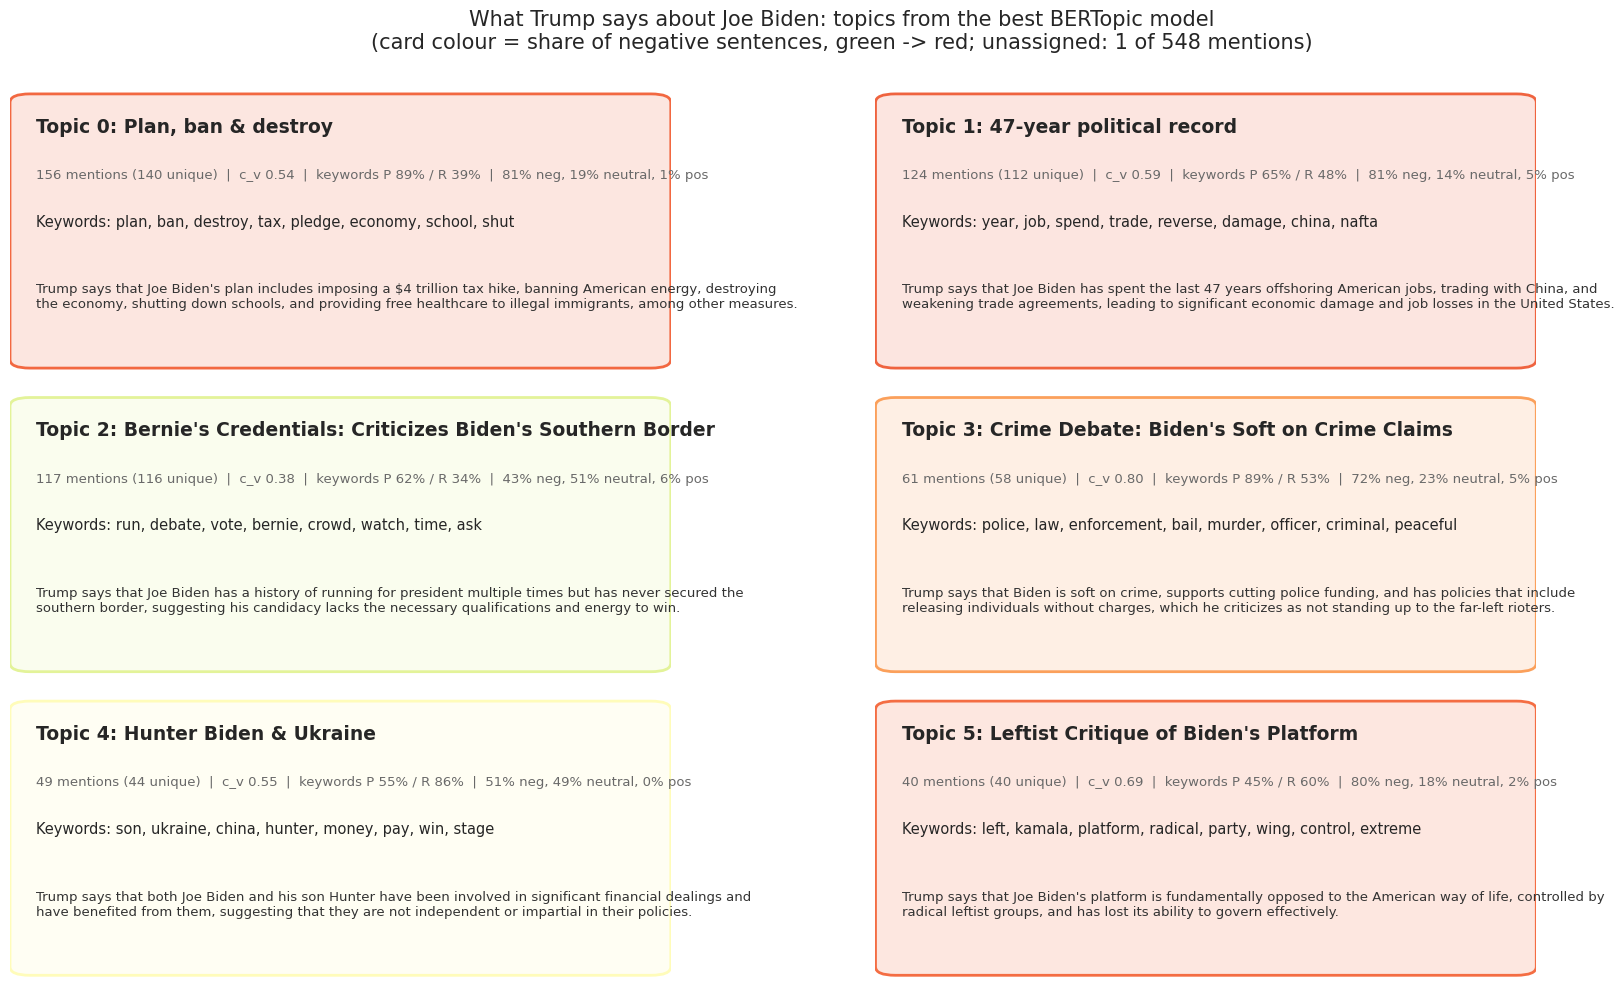

In [37]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgba

cmap = plt.cm.RdYlGn_r
ncols = 2
nrows = max(1, math.ceil(len(topic_summary) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.3 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis("off")
for ax, r in zip(axes, topic_summary.itertuples()):
    ax.add_patch(FancyBboxPatch((0.01, 0.03), 0.98, 0.94, boxstyle="round,pad=0.01,rounding_size=0.03",
                                transform=ax.transAxes, facecolor=to_rgba(cmap(r.Negative), 0.16),
                                edgecolor=cmap(r.Negative), lw=2))
    ax.text(0.04, 0.90, textwrap.shorten(f"Topic {r.Topic}: {r.Label}", 70), transform=ax.transAxes,
            fontsize=13.5, weight="bold", va="top")
    ax.text(0.04, 0.72, f"{r.Mentions} mentions ({r.Unique} unique)  |  c_v {r.c_v:.2f}  |  keywords P {r.Precision:.0%} / R {r.Recall:.0%}  |  "
                        f"{r.Negative:.0%} neg, {r.Neutral:.0%} neutral, {r.Positive:.0%} pos",
            transform=ax.transAxes, fontsize=9.5, color="dimgray", va="top")
    ax.text(0.04, 0.56, textwrap.fill("Keywords: " + r.Keywords, 95), transform=ax.transAxes, fontsize=10.5, va="top")
    ax.text(0.04, 0.32, textwrap.fill(textwrap.shorten(r.Summary, 260), 110),
            transform=ax.transAxes, fontsize=9.5, va="top", color="#333333")
fig.suptitle("What Trump says about Joe Biden: topics from the best BERTopic model\n"
             f"(card colour = share of negative sentences, green -> red; unassigned: {n_un_all} of {len(TOPICS_ALL)} mentions)",
             fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 13.3 Topic overview: size, keyword fit and sentiment

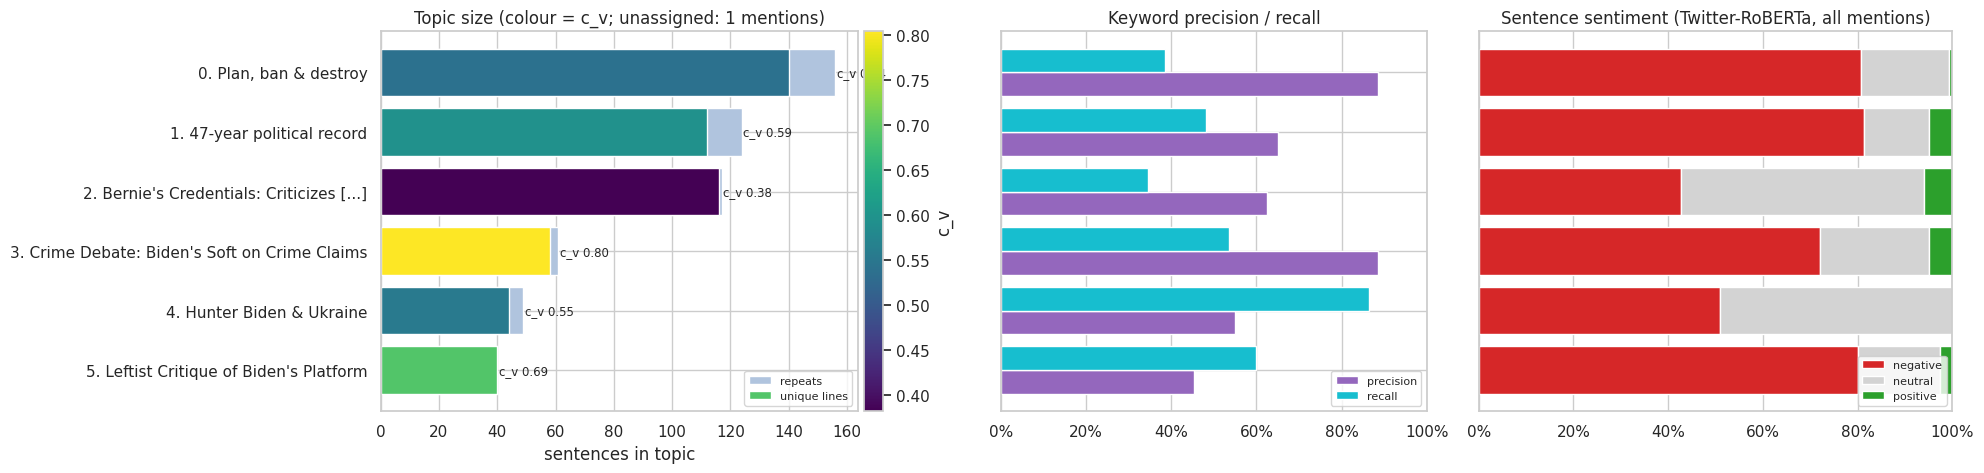

In [38]:
ts = topic_summary.sort_values("Mentions")
ylabels = [textwrap.shorten(f"{t}. {l}", 45) for t, l in zip(ts["Topic"], ts["Label"])]
fig, axes = plt.subplots(1, 3, figsize=(20, 0.45 * len(ts) + 2.2), sharey=True, gridspec_kw={"width_ratios": [1.2, 0.9, 1]})
norm = plt.Normalize(np.nanmin(ts["c_v"]), np.nanmax(ts["c_v"]))
axes[0].barh(ylabels, ts["Mentions"], color="lightsteelblue", label="repeats")
axes[0].barh(ylabels, ts["Unique"], color=plt.cm.viridis(norm(ts["c_v"])), label="unique lines")
for y_, (s, v) in enumerate(zip(ts["Mentions"], ts["c_v"])):
    axes[0].text(s + 0.5, y_, f"c_v {v:.2f}", va="center", fontsize=8.5)
axes[0].set_xlabel("sentences in topic"); axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_title(f"Topic size (colour = c_v; unassigned: {n_un_all} mentions)")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); fig.colorbar(sm, ax=axes[0], label="c_v", pad=0.01)
yy = np.arange(len(ts))
axes[1].barh(yy - 0.2, ts["Precision"], height=0.4, color="tab:purple", label="precision")
axes[1].barh(yy + 0.2, ts["Recall"], height=0.4, color="tab:cyan", label="recall")
axes[1].set_xlim(0, 1); axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_title("Keyword precision / recall"); axes[1].legend(loc="lower right", fontsize=8)
left = np.zeros(len(ts))
for col, color in (("Negative", "tab:red"), ("Neutral", "lightgray"), ("Positive", "tab:green")):
    axes[2].barh(ylabels, ts[col], left=left, color=color, label=col.lower()); left += ts[col].values
axes[2].set_xlim(0, 1); axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[2].set_title("Sentence sentiment (Twitter-RoBERTa, all mentions)"); axes[2].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### 13.4 BERTopic views (static images, with the generated labels and summaries)
Same four views as before (topic overview, document map, topic hierarchy, topics over time), drawn with matplotlib so they stay visible when the notebook is downloaded. What used to be hover text (summaries, example sentences, rally counts) is printed on the charts.

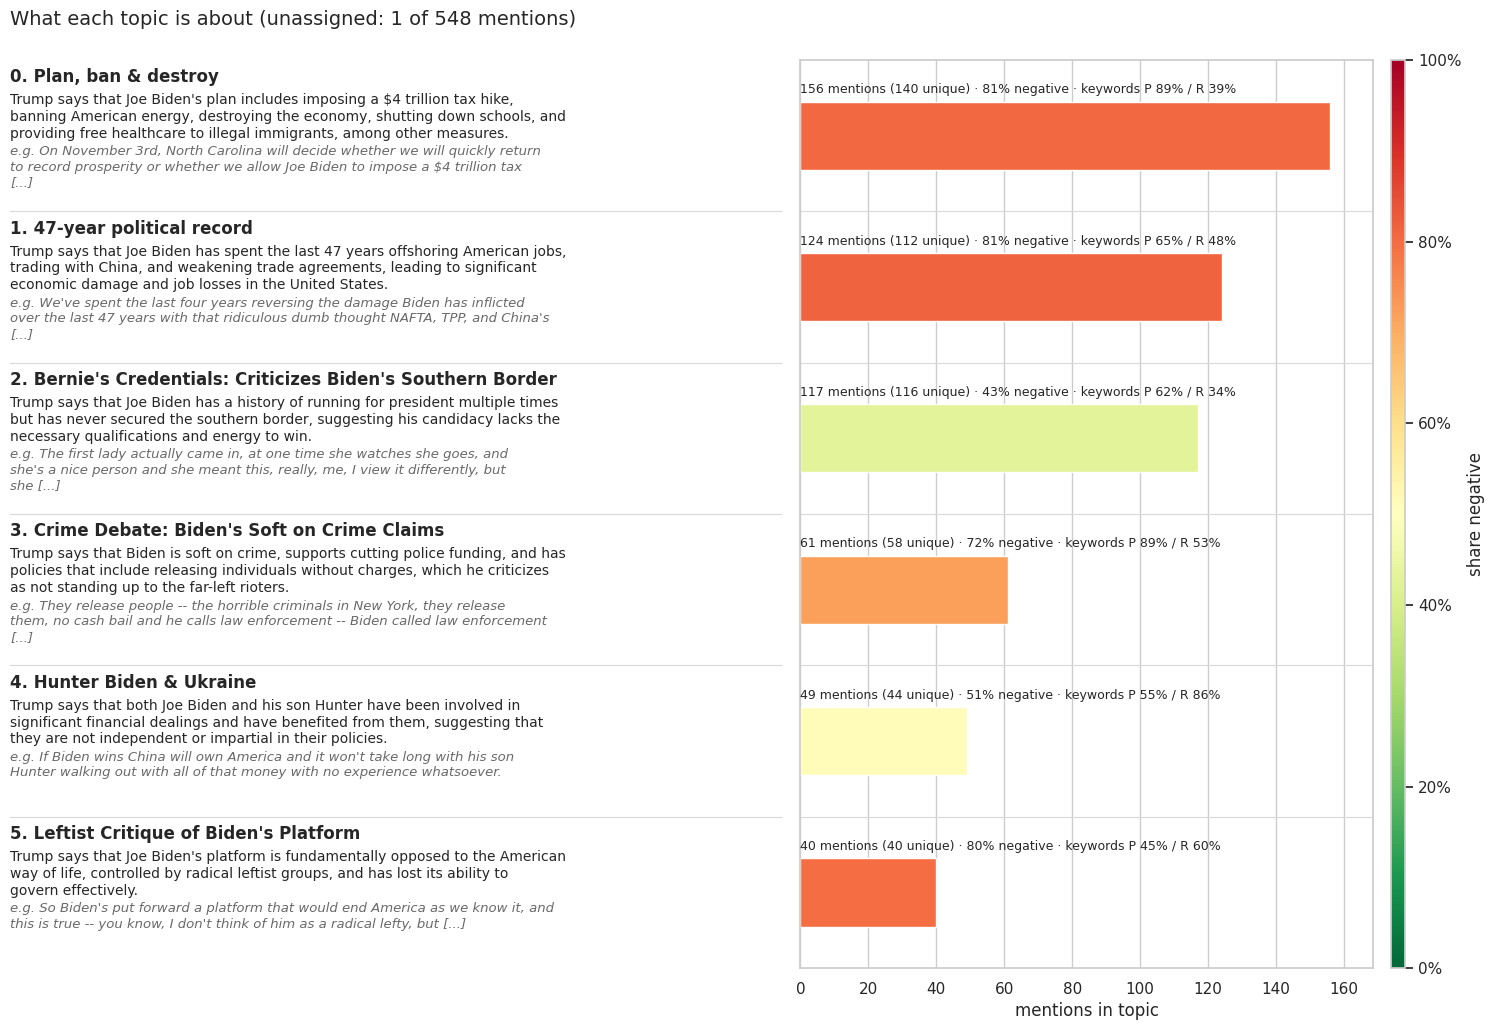

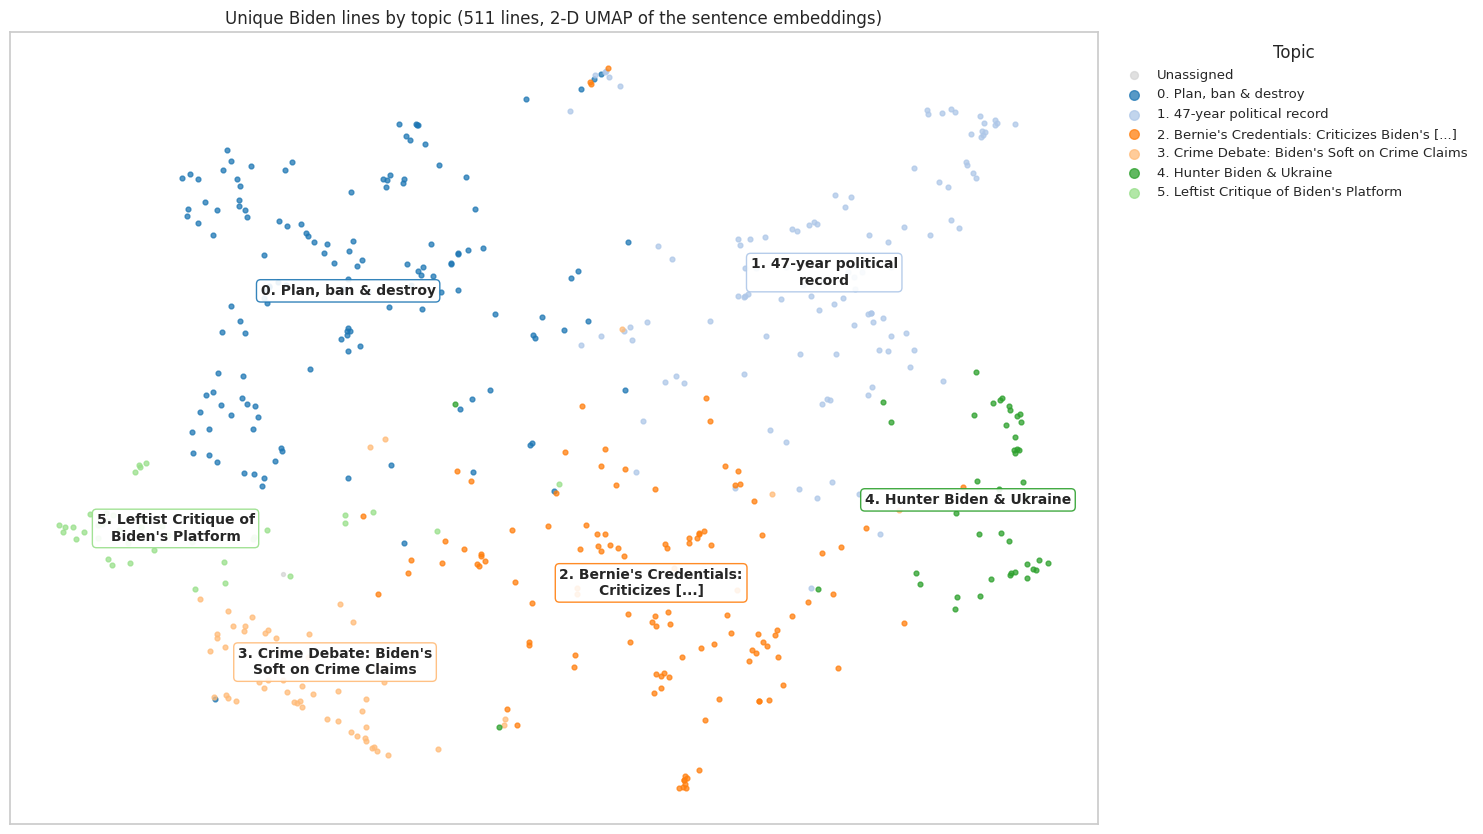

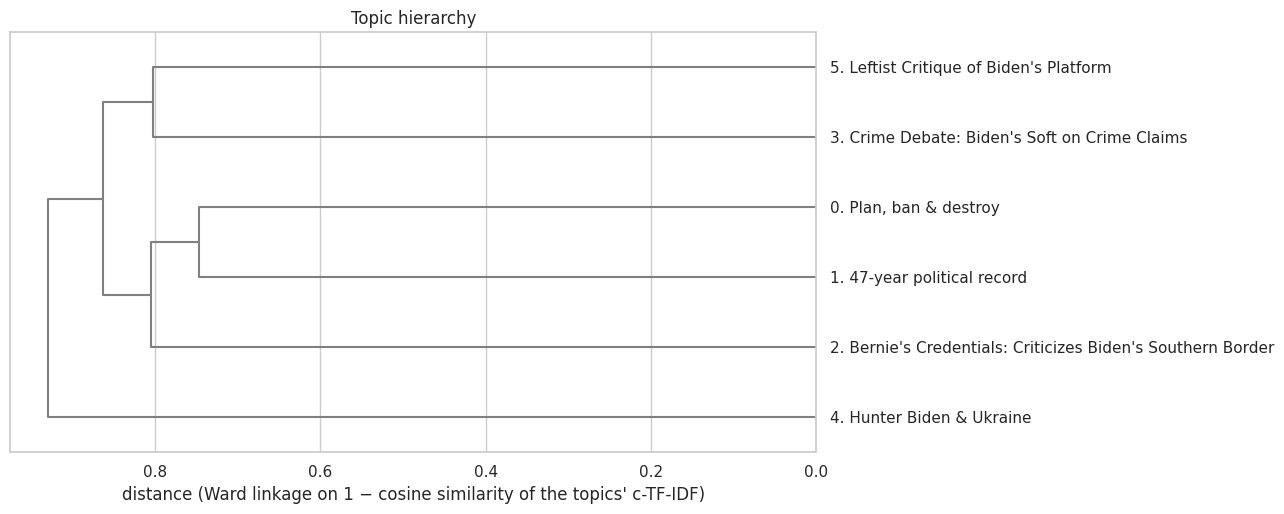

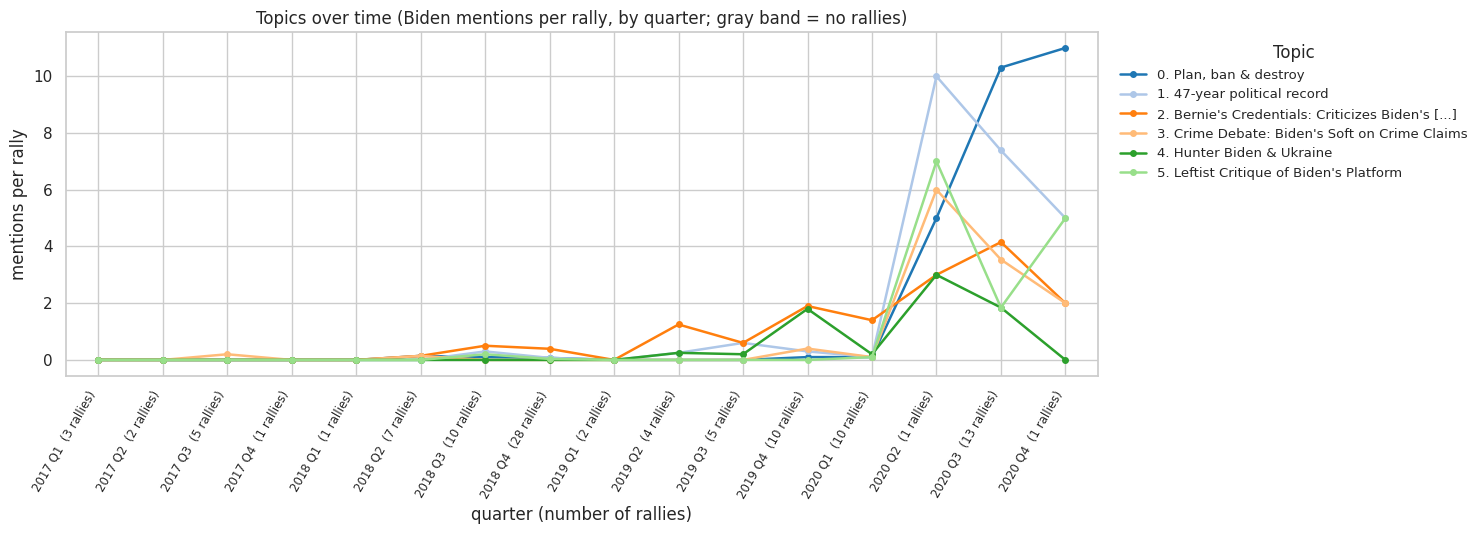

In [39]:
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter
from scipy.cluster import hierarchy as sch
from scipy.spatial.distance import squareform

def safe_show(fn, name):
    try:
        fn()
        plt.show()
    except Exception as ex:
        plt.close("all")
        print(f"{name} skipped: {ex}")

TOPIC_COLORS = {t: plt.cm.tab20(i % 20) for i, t in enumerate(TOPIC_IDS)}

# 1) topic overview: title + readable summary (and an example) next to each topic's size bar
def _overview():
    ts = topic_summary.sort_values("Mentions").reset_index(drop=True)
    blocks = [(textwrap.wrap(s, 80), textwrap.wrap("e.g. " + textwrap.shorten(e, 160), 80))
              for s, e in zip(ts["Summary"], ts["Example"])]
    line_pt = 12.5                                         # height of one text line (points)
    max_lines = max(len(a) + len(b) for a, b in blocks)
    row_h = (18 + max_lines * line_pt + 16) / 72           # inches per topic row
    fig = plt.figure(figsize=(18, len(ts) * row_h + 1.3))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 0.025], wspace=0.04)
    ax_t, ax, cax = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    y = np.arange(len(ts))
    cm, norm = plt.cm.RdYlGn_r, Normalize(0, 1)
    ax.barh(y, ts["Mentions"], height=0.45, color=cm(norm(ts["Negative"].values)))
    for yi, (m, u, n, p, r) in enumerate(zip(ts["Mentions"], ts["Unique"], ts["Negative"], ts["Precision"], ts["Recall"])):
        ax.text(0, yi + 0.26, f"{m} mentions ({u} unique) · {n:.0%} negative · keywords P {p:.0%} / R {r:.0%}",
                fontsize=9, va="bottom", ha="left")
    for a in (ax_t, ax):
        a.set_ylim(-0.5, len(ts) - 0.5)
    ax.set_yticks([]); ax.set_xlim(0, ts["Mentions"].max() * 1.08); ax.set_xlabel("mentions in topic")
    ax.grid(axis="y", visible=False)
    ax_t.axis("off")
    for yi, (t, l, (summ_lines, ex_lines)) in enumerate(zip(ts["Topic"], ts["Label"], blocks)):
        top = ("axes fraction", "data")
        ax_t.annotate(f"{t}. {l}", xy=(0, yi + 0.5), xycoords=top, xytext=(0, -6), textcoords="offset points",
                      fontsize=12, weight="bold", va="top")
        ax_t.annotate("\n".join(summ_lines), xy=(0, yi + 0.5), xycoords=top, xytext=(0, -24),
                      textcoords="offset points", fontsize=10, va="top", linespacing=1.25)
        ax_t.annotate("\n".join(ex_lines), xy=(0, yi + 0.5), xycoords=top,
                      xytext=(0, -24 - len(summ_lines) * line_pt), textcoords="offset points",
                      fontsize=9.5, va="top", style="italic", color="dimgray", linespacing=1.25)
        if yi > 0:
            ax_t.axhline(yi - 0.5, color="0.85", lw=0.8)
            ax.axhline(yi - 0.5, color="0.85", lw=0.8)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm), cax=cax, label="share negative",
                 format=PercentFormatter(1.0))
    fig.subplots_adjust(top=1 - 0.7 / fig.get_figheight(), bottom=0.6 / fig.get_figheight())
    fig.suptitle(f"What each topic is about (unassigned: {n_un_all} of {len(TOPICS_ALL)} mentions)",
                 fontsize=14, x=0.125, ha="left", y=1 - 0.2 / fig.get_figheight())
safe_show(_overview, "Topic overview")

# 2) document map of the unique lines (the model was fitted on these)
reduced_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric="cosine",
                  random_state=SEED).fit_transform(E_U)

def _docmap():
    fig, ax = plt.subplots(figsize=(15, 8.5))
    out = TOPICS_U == -1
    if out.any():
        ax.scatter(reduced_2d[out, 0], reduced_2d[out, 1], s=8, color="lightgray", alpha=0.7, label="Unassigned")
    for t in TOPIC_IDS:
        m = TOPICS_U == t
        name = textwrap.shorten(f"{t}. {LABELS[t]}", 55)
        ax.scatter(reduced_2d[m, 0], reduced_2d[m, 1], s=12, color=TOPIC_COLORS[t], alpha=0.75, label=name)
        cx, cy = reduced_2d[m].mean(axis=0)
        ax.text(cx, cy, textwrap.fill(textwrap.shorten(f"{t}. {LABELS[t]}", 45), 25), fontsize=10, weight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=TOPIC_COLORS[t], alpha=0.9))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9.5, markerscale=2, frameon=False, title="Topic")
    ax.set_title(f"Unique Biden lines by topic ({len(TOPICS_U)} lines, 2-D UMAP of the sentence embeddings)")
    plt.tight_layout()
safe_show(_docmap, "Document map")

# 3) topic hierarchy: same recipe as BERTopic's visualize_hierarchy (1 - cosine of c-TF-IDF, Ward linkage)
def _hierarchy():
    if len(TOPIC_IDS) < 2:
        raise ValueError("needs at least two topics")
    all_t = sorted(final_model.get_topics().keys())
    X = final_model.c_tf_idf_[[all_t.index(t) for t in TOPIC_IDS]]
    D = 1 - cosine_similarity(X)
    D = np.clip((D + D.T) / 2, 0, None)
    np.fill_diagonal(D, 0)
    Z = sch.linkage(squareform(D, checks=False), "ward", optimal_ordering=True)
    fig, ax = plt.subplots(figsize=(13, 0.55 * len(TOPIC_IDS) + 2))
    sch.dendrogram(Z, orientation="left", ax=ax, above_threshold_color="gray",
                   labels=[textwrap.shorten(f"{t}. {LABELS[t]}", 60) for t in TOPIC_IDS], leaf_font_size=11)
    ax.set_xlabel("distance (Ward linkage on 1 − cosine similarity of the topics' c-TF-IDF)")
    ax.set_title("Topic hierarchy"); ax.grid(axis="y", visible=False)
    plt.tight_layout()
safe_show(_hierarchy, "Hierarchy")

# 4) topics over time: mentions (repeats included) per rally in each quarter
def _tot():
    d = info[info["Topic"] != -1].copy()
    d["Quarter"] = pd.to_datetime(d["Date"]).dt.to_period("Q")
    rallies_q = df["Date_parsed"].dt.to_period("Q").value_counts().sort_index()
    all_q = pd.period_range(rallies_q.index.min(), rallies_q.index.max(), freq="Q")
    counts = d.groupby(["Quarter", "Topic"]).size().unstack(fill_value=0).reindex(all_q, fill_value=0)
    n_rallies = rallies_q.reindex(all_q)
    per_rally = counts.div(n_rallies, axis=0)
    x = [f"{q.year} Q{q.quarter}  ({int(n) if pd.notna(n) else 0} rallies)" for q, n in zip(all_q, n_rallies)]
    xs = np.arange(len(all_q))
    fig, ax = plt.subplots(figsize=(15, 5.5))
    for k, n in enumerate(n_rallies):
        if pd.isna(n):
            ax.axvspan(k - 0.5, k + 0.5, color="0.93", lw=0)   # quarter without rallies (line is broken here)
    for t in topic_summary["Topic"]:
        y = per_rally[t] if t in per_rally else pd.Series(np.nan, index=all_q)
        ax.plot(xs, y.values, "o-", ms=4, lw=1.8, color=TOPIC_COLORS.get(t, "gray"),
                label=textwrap.shorten(f"{t}. {LABELS[t]}", 55))
    ax.set_xticks(xs); ax.set_xticklabels(x, rotation=60, ha="right", fontsize=8.5)
    ax.set_xlim(-0.5, len(xs) - 0.5)
    ax.set_xlabel("quarter (number of rallies)"); ax.set_ylabel("mentions per rally")
    ax.set_title("Topics over time (Biden mentions per rally, by quarter; gray band = no rallies)")
    ax.legend(title="Topic", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9.5, frameon=False)
    plt.tight_layout()

if all(pd.notna(d) for d in DOCS_DATES):
    safe_show(_tot, "Topics over time")
else:
    print("Topics over time skipped: some rally dates could not be parsed.")